<a href="https://colab.research.google.com/github/Oksi193/Statistical-Modelling/blob/main/Clustering_K_means_Credit_Card.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clustering Credit Card

## Tujuan
- Membangun model (Clustering) yang akurat untuk mengidentifikasi pola data dan menentukan jumlah segmen pelanggan yang paling optimal.
- Merumuskan strategi bisnis yang dipersonalisasi bagi setiap kelompok pelanggan yang terbentuk guna meningkatkan kepuasan, loyalitas, dan kepercayaan nasabah terhadap perusahaan.

## Data
Data yang digunakan berasal dari kaggle, terdiri dari 8950 amatan dan 18 Variable yaitu:

- CUST_ID: Identifikasi pemegang Kartu Kredit (Kategorikal).

- BALANCE: Jumlah saldo yang tersisa di akun pelanggan yang bisa digunakan untuk melakukan pembelian.

- BALANCE_FREQUENCY: Seberapa sering saldo diperbarui, berupa skor antara 0 dan 1 (1 = sering diperbarui, 0 = jarang diperbarui).

- PURCHASES: Total nominal pembelian yang dilakukan dari akun tersebut.

- ONEOFF_PURCHASES: Total nominal pembelian yang dilakukan dalam satu kali transaksi penuh (bukan cicilan / dibayar sekaligus).

- INTALLMENTS_PURCHASES: Total nominal pembelian yang dilakukan dengan sistem cicilan.

- CASH_ADVANCE: Total penarikan tunai (cash advance) yang dilakukan oleh pengguna dari kartu kreditnya.

- PURCHASES_FREQUENCY: Seberapa sering pembelian dilakukan, berupa skor antara 0 dan 1 (1 = sering melakukan pembelian, 0 = jarang melakukan pembelian).

- ONEOFF_PURCHASES_FREQUENCY: Seberapa sering pembelian secara sekaligus (satu kali bayar penuh) dilakukan, skor antara 0 dan 1 (1 = sering, 0 = jarang).

- PURCHASES_INSTALLMENTS_FREQUENCY: Seberapa sering pembelian dengan sistem cicilan dilakukan, skor antara 0 dan 1 (1 = sering, 0 = jarang).

- CASH_ADVANCE_FREQUENCY: Seberapa sering penarikan tunai (cash advance) dilakukan.

- CASH_ADVANCE_TRX: Jumlah total transaksi penarikan tunai (cash advance) yang dilakukan.

- PURCHASES_TRX: Jumlah total transaksi pembelian yang dilakukan.

- CREDIT_LIMIT: Batas maksimal limit Kartu Kredit yang diberikan kepada pengguna.

- PAYMENTS: Total nominal pembayaran tagihan yang telah dilakukan oleh pengguna.

- MINIMUM_PAYMENTS: Total nominal pembayaran minimum yang telah dibayarkan oleh pengguna.

- PRC_FULL_PAYMENT: Persentase tagihan yang dibayar secara penuh oleh pengguna (tidak dicicil/tidak bayar minimum).

- TENURE: Masa pakai atau lamanya waktu (tenor) pengguna telah menggunakan layanan kartu kredit tersebut (biasanya dalam hitungan bulan).

## Data Pre-processing

In [19]:
import pandas as pd
import numpy as np
import kagglehub
import os

# Package untuk visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Package untuk cleaning, modelling, dan evaluation model
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial import ConvexHull

import warnings
warnings.simplefilter("ignore")

In [20]:
# Import data dari kaggle
path = kagglehub.dataset_download("arjunbhasin2013/ccdata")

print("Path to dataset files:", path)

# Melihat daftar file yang ada di dalam variabel 'path'
file_list = os.listdir(path)
print("File yang tersedia:", file_list)

# Mencari file .csv
csv_filename = [file for file in file_list if file.endswith('.csv')][0]
full_file_path = os.path.join(path, csv_filename)

# Membaca file CSV menjadi DataFrame Pandas
data = pd.read_csv(full_file_path)

# Rename Data
data.rename(columns={
    'CUST_ID': 'Cust_ID',
    'BALANCE': 'Saldo (USD)',
    'BALANCE_FREQUENCY': 'Frekuensi_Saldo',
    'PURCHASES': 'Pembelian',
    'ONEOFF_PURCHASES': 'Pembelian_Satu_Kali',
    'INSTALLMENTS_PURCHASES': 'Pembelian_Angsuran',
    'CASH_ADVANCE': 'Uang_Dibayar_Dimuka',
    'PURCHASES_FREQUENCY': 'Frekuensi_Pembelian',
    'ONEOFF_PURCHASES_FREQUENCY': 'Frekuensi_Pembelian_Satu_Kali',
    'PURCHASES_INSTALLMENTS_FREQUENCY': 'Frekuensi_Pembelian_Angsuran',
    'CASH_ADVANCE_FREQUENCY': 'Frekuensi_Uang_Dibayar_Dimuka',
    'CASH_ADVANCE_TRX': 'Transaksi_Uang_Dibayar_Dimuka',
    'PURCHASES_TRX': 'Transaksi_Pembelian',
    'CREDIT_LIMIT': 'Batas_Kredit',
    'PAYMENTS': 'Pembayaran',
    'MINIMUM_PAYMENTS': 'Pembayaran_Minimal',
    'PRC_FULL_PAYMENT': 'Pembelian_Pembayaran_Penuh',
    'TENURE': 'Tenor'
}, inplace=True)

# Menampilkan 5 baris pertama
display(data.head(5))
print("---------------------------------------------------------------------------------------------------------------------------------------------")

# Data Info
data.info()

Using Colab cache for faster access to the 'ccdata' dataset.
Path to dataset files: /kaggle/input/ccdata
File yang tersedia: ['CC GENERAL.csv']


,Cust_ID,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


---------------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Cust_ID                        8950 non-null   object 
 1   Saldo (USD)                    8950 non-null   float64
 2   Frekuensi_Saldo                8950 non-null   float64
 3   Pembelian                      8950 non-null   float64
 4   Pembelian_Satu_Kali            8950 non-null   float64
 5   Pembelian_Angsuran             8950 non-null   float64
 6   Uang_Dibayar_Dimuka            8950 non-null   float64
 7   Frekuensi_Pembelian            8950 non-null   float64
 8   Frekuensi_Pembelian_Satu_Kali  8950 non-null   float64
 9   Frekuensi_Pembelian_Angsuran   8950 non-null   float64
 10  Frekuensi_Uang_Dibayar_Dim

Informasi data :
- Terdapat 18 kolom yang terdiri dari 8950 data.
- Terdapat missing value pada kolom batas_kredit dan pembayaran minimal.
- Pada dataset terdapat 1 tipe data objek, 3 tipe data integer dan 14 tipe data float.

In [21]:
# Summary Data dengan format justify
data.describe().round(1).style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.500000,0.900000,1003.200000,592.400000,411.100000,978.900000,0.500000,0.200000,0.400000,0.100000,3.200000,14.700000,4494.400000,1733.100000,864.200000,0.200000,11.500000
std,2081.500000,0.200000,2136.600000,1659.900000,904.300000,2097.200000,0.400000,0.300000,0.400000,0.200000,6.800000,24.900000,3638.800000,2895.100000,2372.400000,0.300000,1.300000
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.000000,0.000000,6.000000
25%,128.300000,0.900000,39.600000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.300000,169.100000,0.000000,12.000000
50%,873.400000,1.000000,361.300000,38.000000,89.000000,0.000000,0.500000,0.100000,0.200000,0.000000,0.000000,7.000000,3000.000000,856.900000,312.300000,0.000000,12.000000
75%,2054.100000,1.000000,1110.100000,577.400000,468.600000,1113.800000,0.900000,0.300000,0.800000,0.200000,4.000000,17.000000,6500.000000,1901.100000,825.500000,0.100000,12.000000
max,19043.100000,1.000000,49039.600000,40761.200000,22500.000000,47137.200000,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.500000,76406.200000,1.000000,12.000000


Summary Data:
1. Saldo rata rata customer adalah 1564.47, terdapat customer yang memiliki jumlah saldo 0, dan terdapat customer dengan dengan jumlah saldo maksimal 19043.14.
2. Rata rata frekuensi saldo pelanggan adalah 0.877 sehingga customer memiliki perilaku sering memperbarui saldo, kemudian terdapat pelanggan yang memiliki frekuensi saldo 0 yang artinya terdapat pelanggan yang sangat jarang memperbarui saldo.
3. Rata rata pembelian dari customer adalah 1003.204 dengan pembelian minimal 0 dan pembelian maksimal 49039.5.
4. Rata rata pembelian sekali jalan sebesar 593.47, dengan minimal pembelian sekalian jalan adalah 0 dan maksimal 40761.250000.
5. Rata rata pembelian secara angsuran sebesar 411.067 dengan pembelian angsuran minimal 0 dan pembelian secara angsuran maksimal sebesar 40761.25.
6. Rata rata uang tunai yang diberikan dimuka sebesar 978.87 dengan pembayaran muka minimal 0 dan maksimal 47137.21.
7. Rata rata frekuensi pembelian sebesar 0.49 sehingga perilaku tidak terlalu sering melakukan pembelian.
8. Rata rata frekuensi pembelian satu kali terjadi adalah 0.2 artinya para pelanggan sangat jarang untuk melakukan pembyaran sekali jalan.
9. Rata rata frekuensi pembayaran angsuran adalah 0.36 sehingga customer memiliki perilaku jarang melakukan pembayaran angsuran.
10. Rata rata frekuensi pembayaran dimuka adalah 0.13 sehingga customer memiliki perilaku jarang melakukan pembayaran uang muka sekali lunas.
11. Rata rata uang transaksi dimuka adalah 3.24, sehingga customer memiliki perilaku melakukan pembayaran uang muka dengan jumlah yang kecil.
12. Rata rata pembayaran minimal sebesar 864.20.
13. Customer didominasi oleh customer yang sudah menikmati jasa bank selama 11 hingga 12 tahun.



In [22]:
customer = data.drop('Cust_ID',axis=1)
customer.head().style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor
0,40.900749,0.818182,95.400000,0.000000,95.400000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.000000,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.000000,0.000000,0.000000,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.000000,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.170000,773.170000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.000000,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.000000,1499.000000,0.000000,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.000000,0.000000,nan,0.000000,12
4,817.714335,1.000000,16.000000,16.000000,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.000000,678.334763,244.791237,0.000000,12


In [23]:
round((((customer.isnull().sum())/customer.shape[0])*100),2)

,0
Saldo (USD),0.00
Frekuensi_Saldo,0.00
Pembelian,0.00
Pembelian_Satu_Kali,0.00
Pembelian_Angsuran,0.00
Uang_Dibayar_Dimuka,0.00
Frekuensi_Pembelian,0.00
Frekuensi_Pembelian_Satu_Kali,0.00
Frekuensi_Pembelian_Angsuran,0.00
Frekuensi_Uang_Dibayar_Dimuka,0.00


kolom pembayaran minimal memiliki missing value sebesar 3.5% dan kolom batas kredit memiliki missing value sebesar 0.01%, karena missing value tergolong sangat kecil maka akan dilakukan penghapusan missing value

In [24]:
customer = customer.dropna().reset_index(drop=True)
customer.head().style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor
0,40.900749,0.818182,95.400000,0.000000,95.400000,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.000000,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.000000,0.000000,0.000000,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.000000,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.170000,773.170000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.000000,622.066742,627.284787,0.000000,12
3,817.714335,1.000000,16.000000,16.000000,0.000000,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.000000,678.334763,244.791237,0.000000,12
4,1809.828751,1.000000,1333.280000,0.000000,1333.280000,0.000000,0.666667,0.000000,0.583333,0.000000,0,8,1800.000000,1400.057770,2407.246035,0.000000,12


## Exploratory Data Analysis

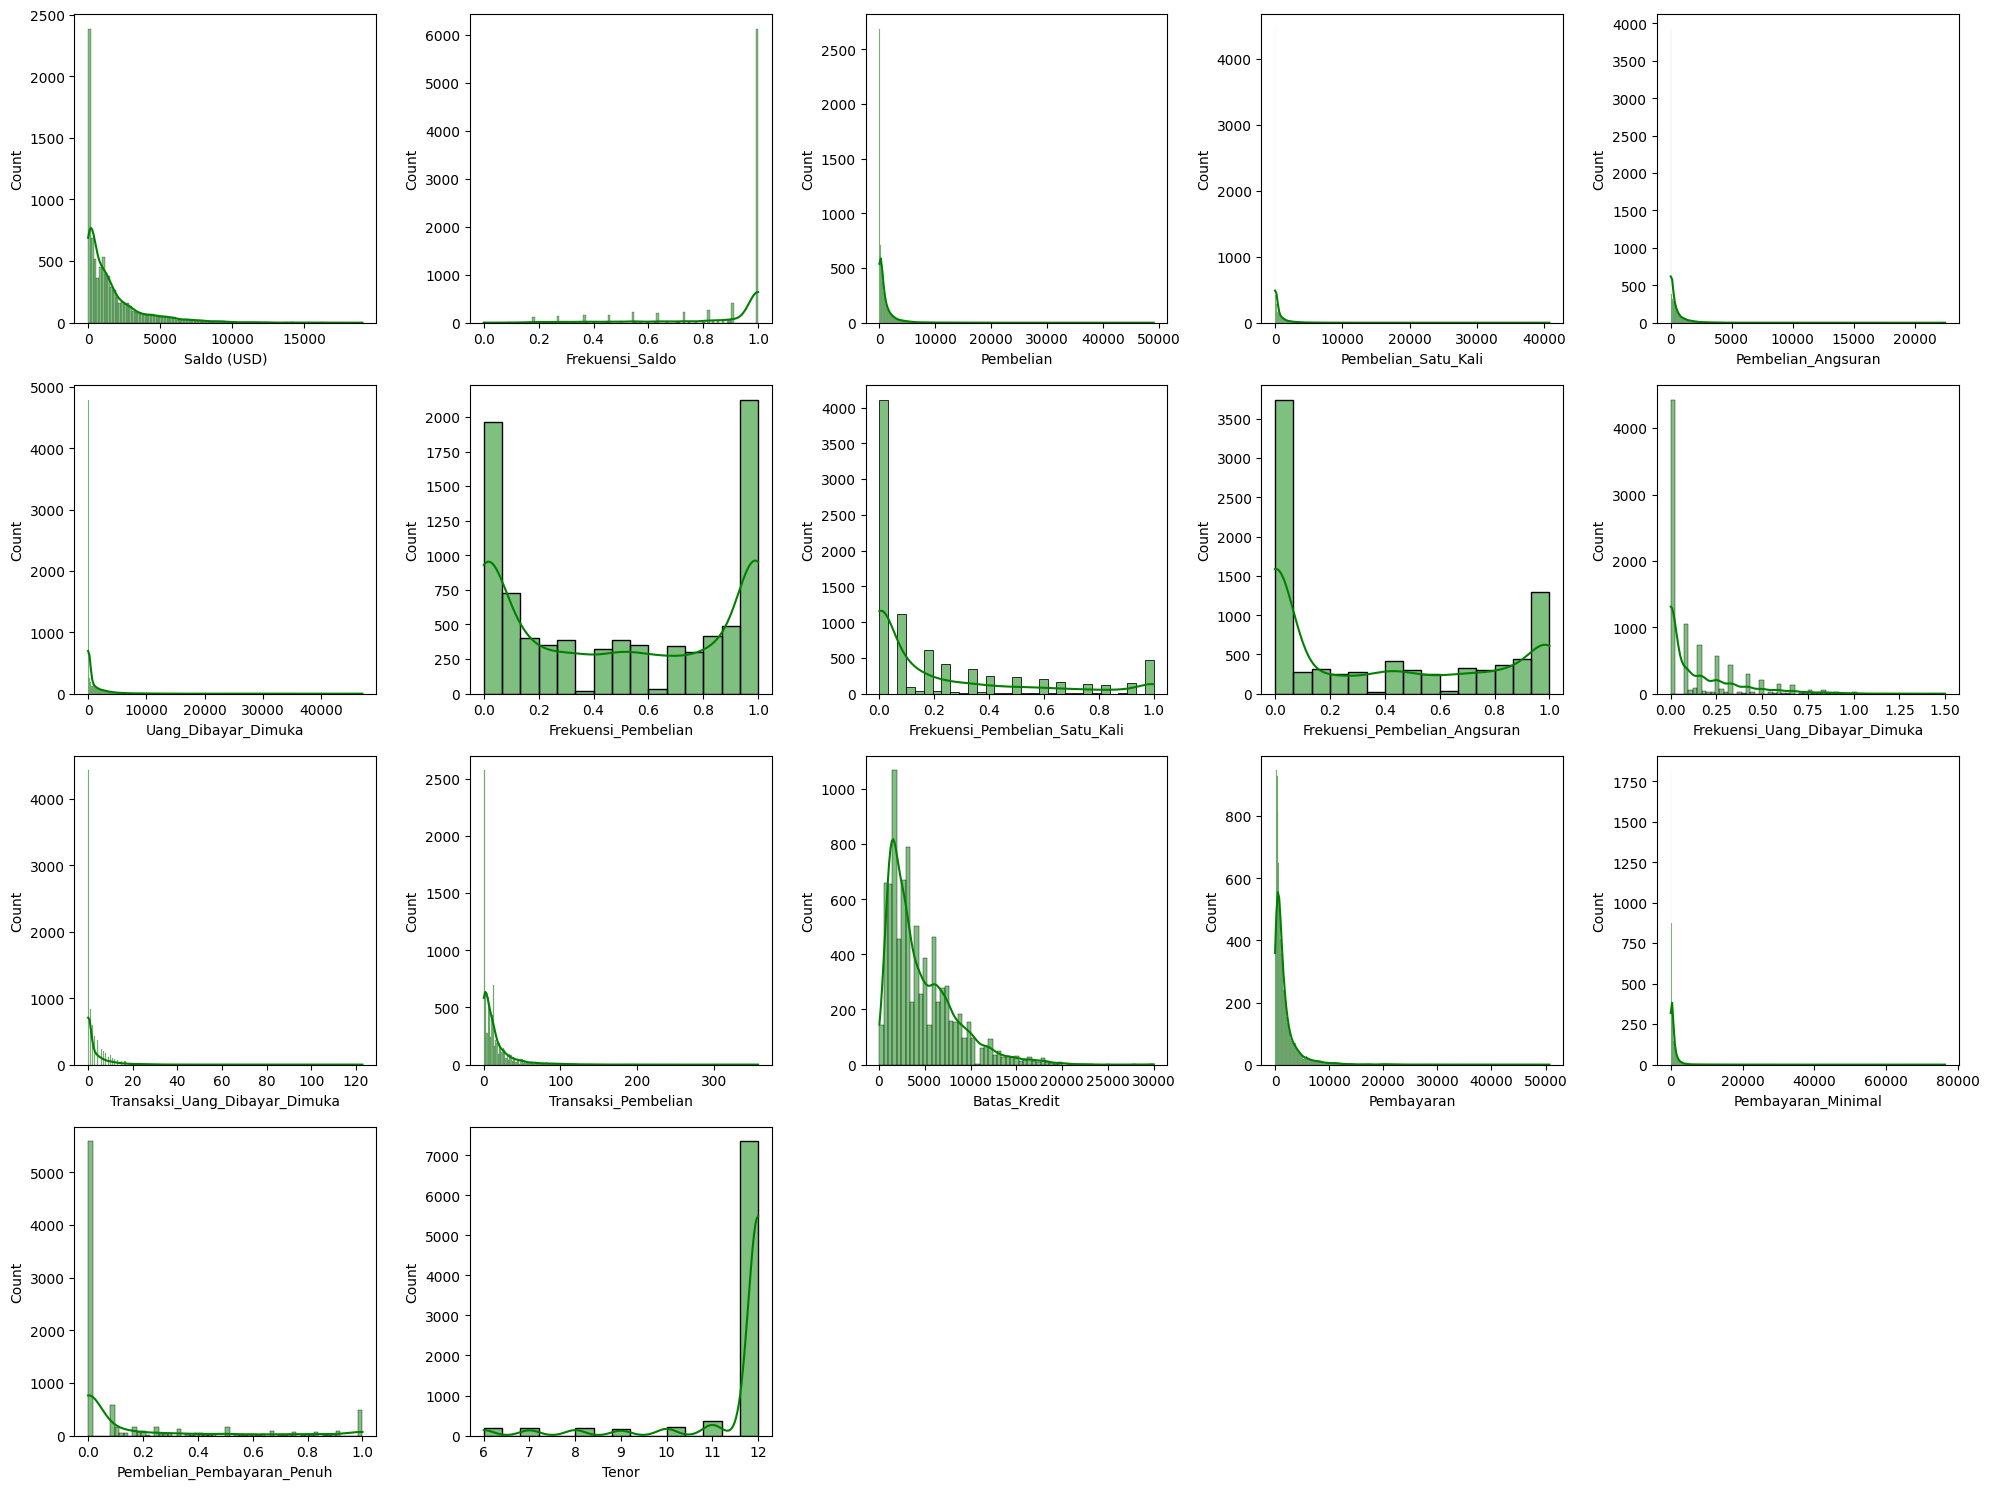

In [25]:
# Membuat histogram masing-masing variable

plt.figure(figsize=(20, 15))
num = customer.select_dtypes(include=['int64', 'float64']).columns
for i in range(0, len(num)):
    plt.subplot(4, 5, i+1)
    sns.histplot(customer[num[i]], color='green', kde=True)

# 2. tight_layout()
plt.tight_layout()
plt.show()

Dari hasil Visualisasi histogram didapatan beberapa informasi:
1. Customer didominasi dengan jumlah saldo pada interval 0 hingga 5000.
2. Customer didominasi oleh orang-orang yang sering melakukan pembaruan saldo.
3. Customer didominasi oleh orang-orang yang melakukan jumlah pembelian pada interval 0 hingga 1200.
4. Customer didominasi dengan pembelian satu kali dengan jumlah pada interval 0-500.

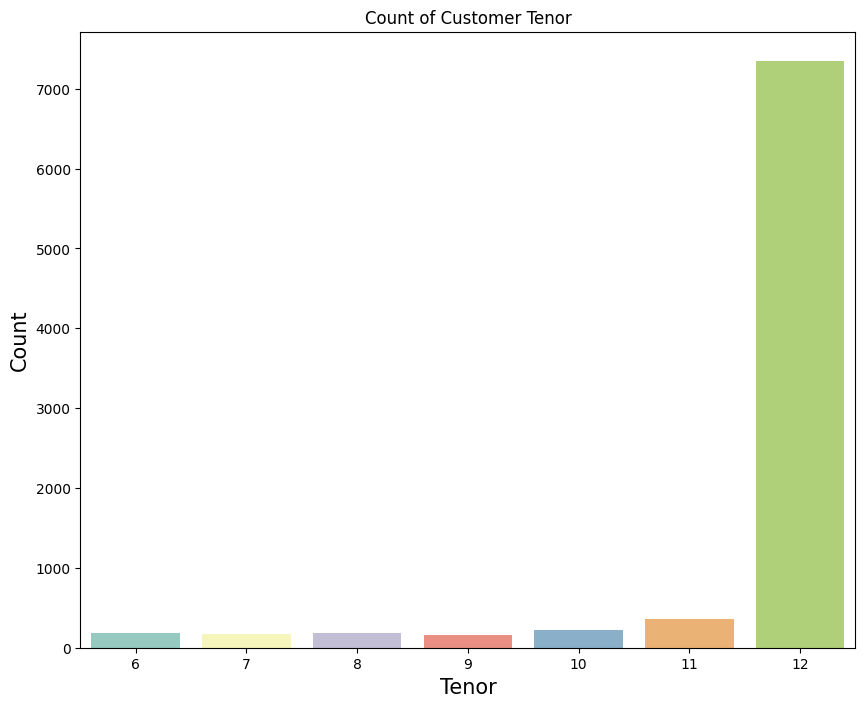

In [26]:
plt.figure(figsize=(10,8))

# Menambahkan hue, palette, dan legend=False
sns.countplot(data=customer, x='Tenor', palette='Set3', legend=False)

plt.title('Count of Customer Tenor')
plt.xlabel('Tenor', fontsize=15)
plt.ylabel('Count', fontsize=15)
plt.show()

1. Customer didominasi oleh tenor 12 sangat banyak dibandingkan dengan yang lain, disusul pada tenor 11dan 10, sedangkan tenor 6,7,8, dan 9 memiliki nilai yang relative sama.
2. Sebanyak 7346 customer yang telah menggunakan jasa bank selama 12 tahun, artinya banyak cutomer yang loyal hingga 12 tahun dan juga percaya terhadap pelayanan yang telah diberikan oleh bank.

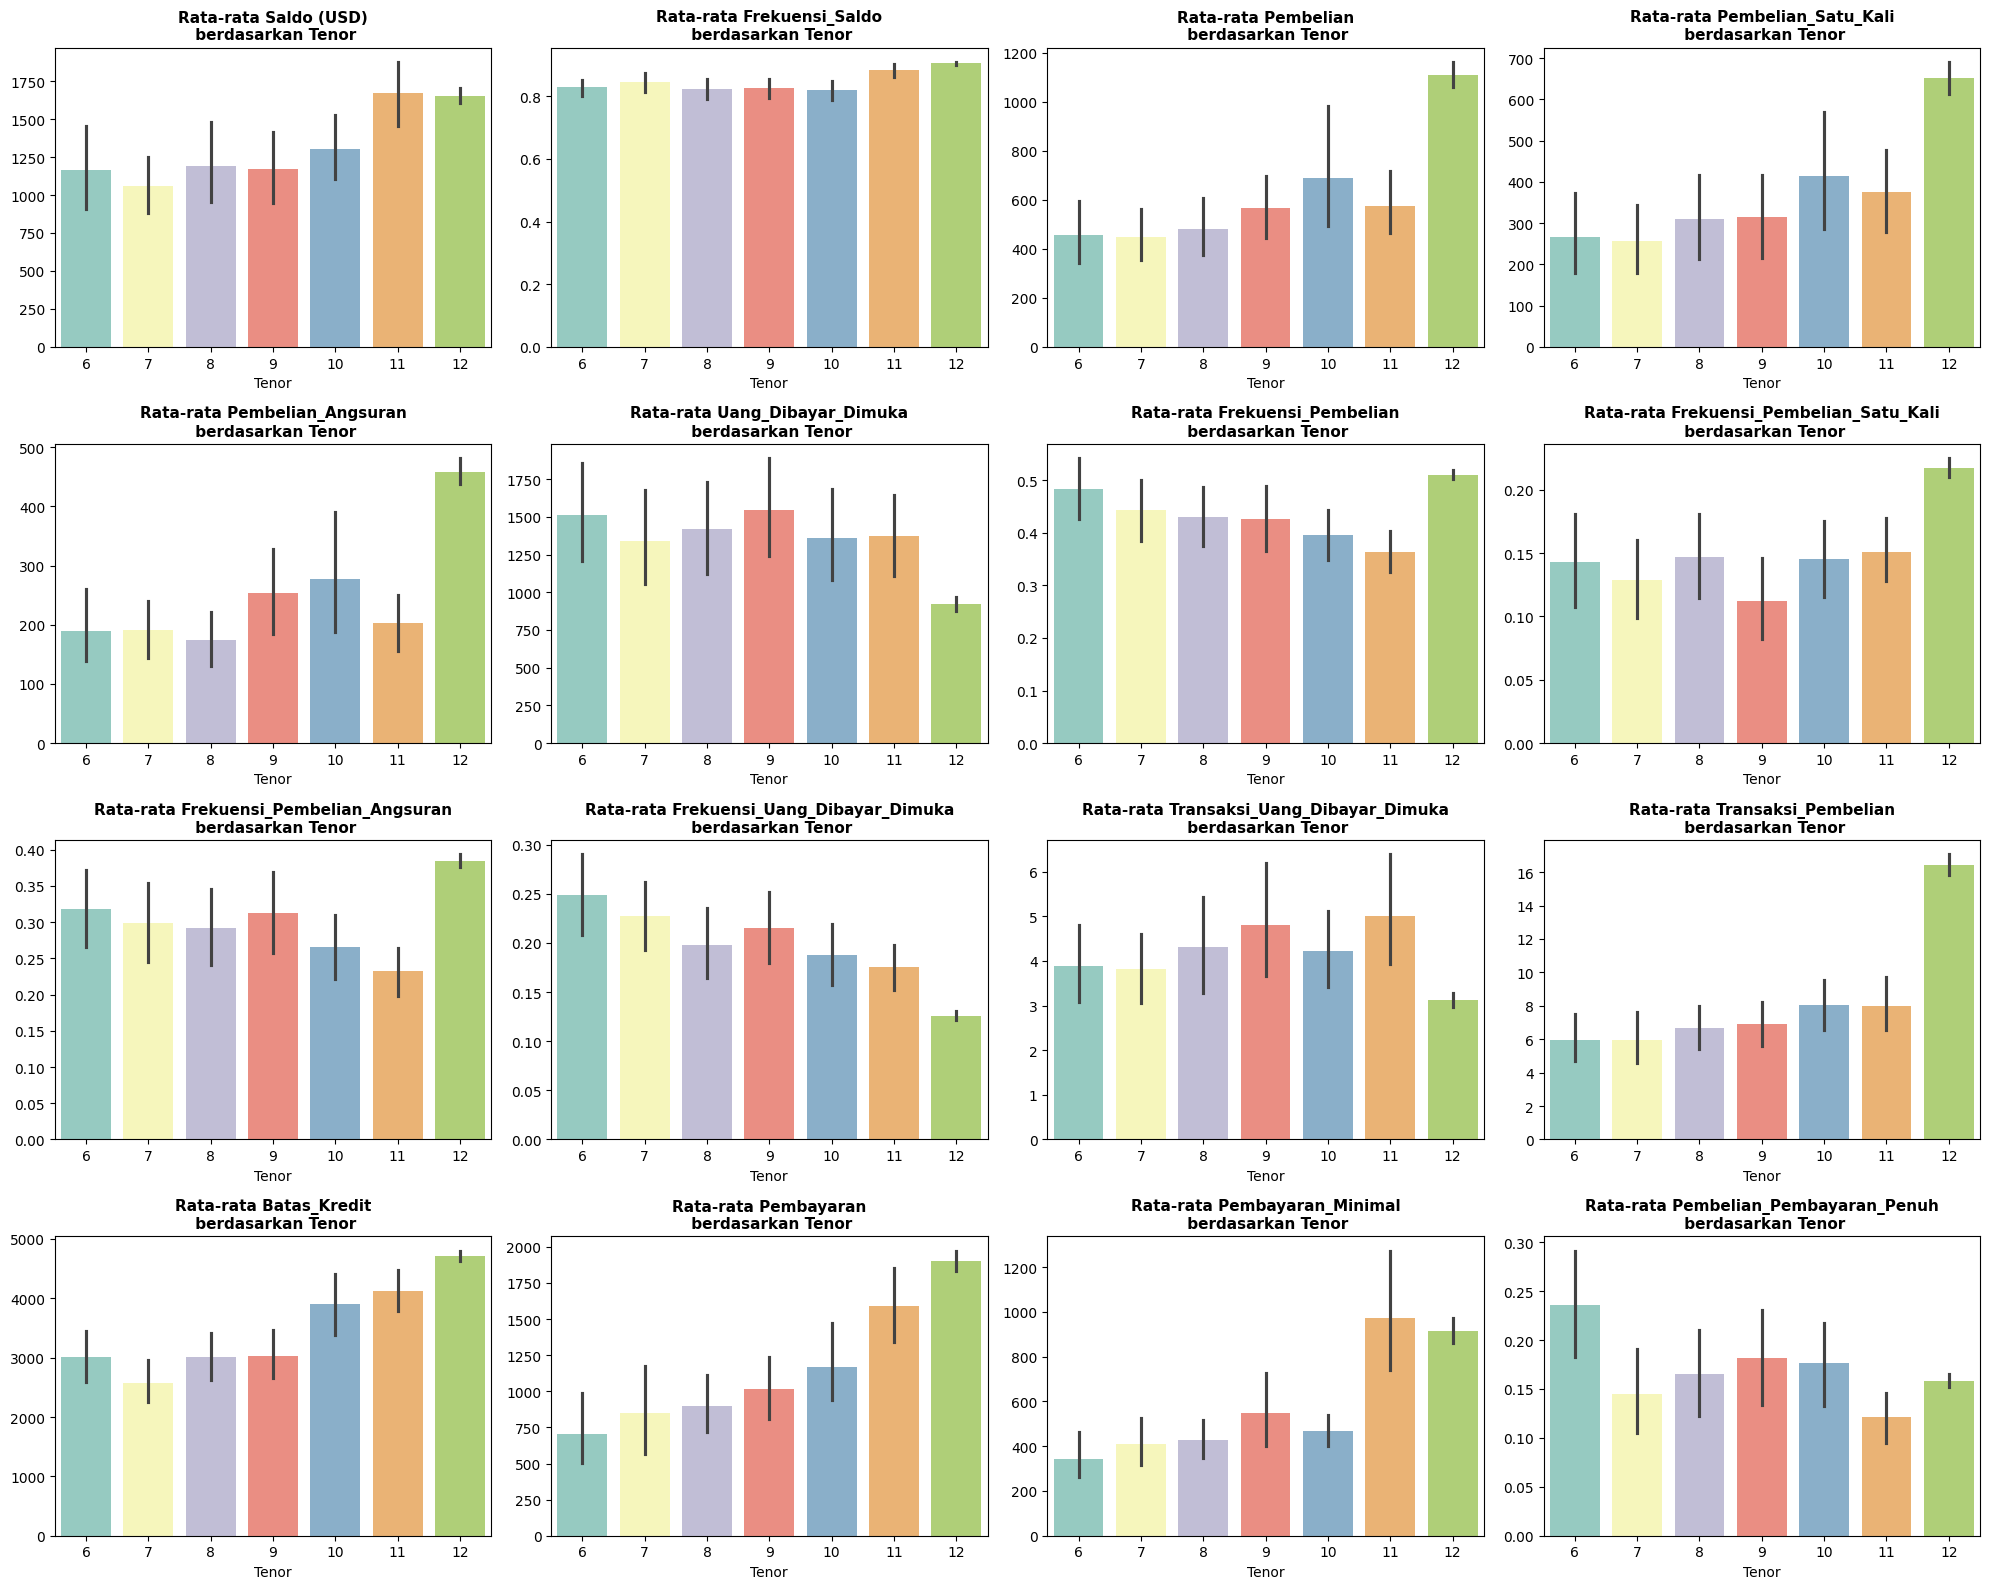

In [27]:
col = ['Saldo (USD)', 'Frekuensi_Saldo', 'Pembelian', 'Pembelian_Satu_Kali',
       'Pembelian_Angsuran', 'Uang_Dibayar_Dimuka', 'Frekuensi_Pembelian',
       'Frekuensi_Pembelian_Satu_Kali', 'Frekuensi_Pembelian_Angsuran',
       'Frekuensi_Uang_Dibayar_Dimuka', 'Transaksi_Uang_Dibayar_Dimuka',
       'Transaksi_Pembelian', 'Batas_Kredit', 'Pembayaran',
       'Pembayaran_Minimal', 'Pembelian_Pembayaran_Penuh']


plt.figure(figsize=(20, 16))

for i in range(len(col)):
    # grid 4x4
    plt.subplot(4, 4, i+1)

    # palet warna
    sns.barplot(data= customer, x='Tenor', y=col[i], palette='Set3', legend=False)
    # Menambahkan judul
    plt.title(f"Rata-rata {col[i]}\n berdasarkan Tenor", fontsize=11, fontweight='bold')
    plt.xlabel('Tenor')
    plt.ylabel('')

# 4. Panggil tight_layout
plt.tight_layout()

plt.show()

Berdasarkan grafik bar plot beberapa informasi yang didapatkan adalah :
1. Kecendrungan peningkatan saldo terhadap waktu pemakaian jasa, hubungannya semakin lama customer maka saldo yang dimiliki samkin besar.
2. Customer yang sudah 12 tahun menggunakan jasa bank, memiliki pembelian yang tinggi, dari grafik juga ditunjukkan secara umum semakin lama tenor customer, maka perilaku pembelian semakin meningkat.
3. Terdapat kasus unik untuk hubungan frekuensi pembelian dengan lama tenor, dimana pada customer dengan tenor 6 tahun lebih sering melakukan pembelian, ketika tenor meningkat kecendrungan frekuensi pembelian menurun tetapi meningkat kembali secara signifikant pada saat customer memiliki tenor 12 tahun.
4. Untuk frekuensi pembayaran dimuka, ketika mengalami penurunan ketikan tenor meningkat.
5. Batas kredit meningkat ketika tenor meningkat, hal ini cukup masuk akal karena peningkatan saldo juga meningkat, sehingga kemungkinan customer akan meningkatkan jumlah limit dengan keperluan tertentu, pernyataan ini didukung dengan hubungan pembayaran dengan tenor yang meningkat seiring tenor meningkat.

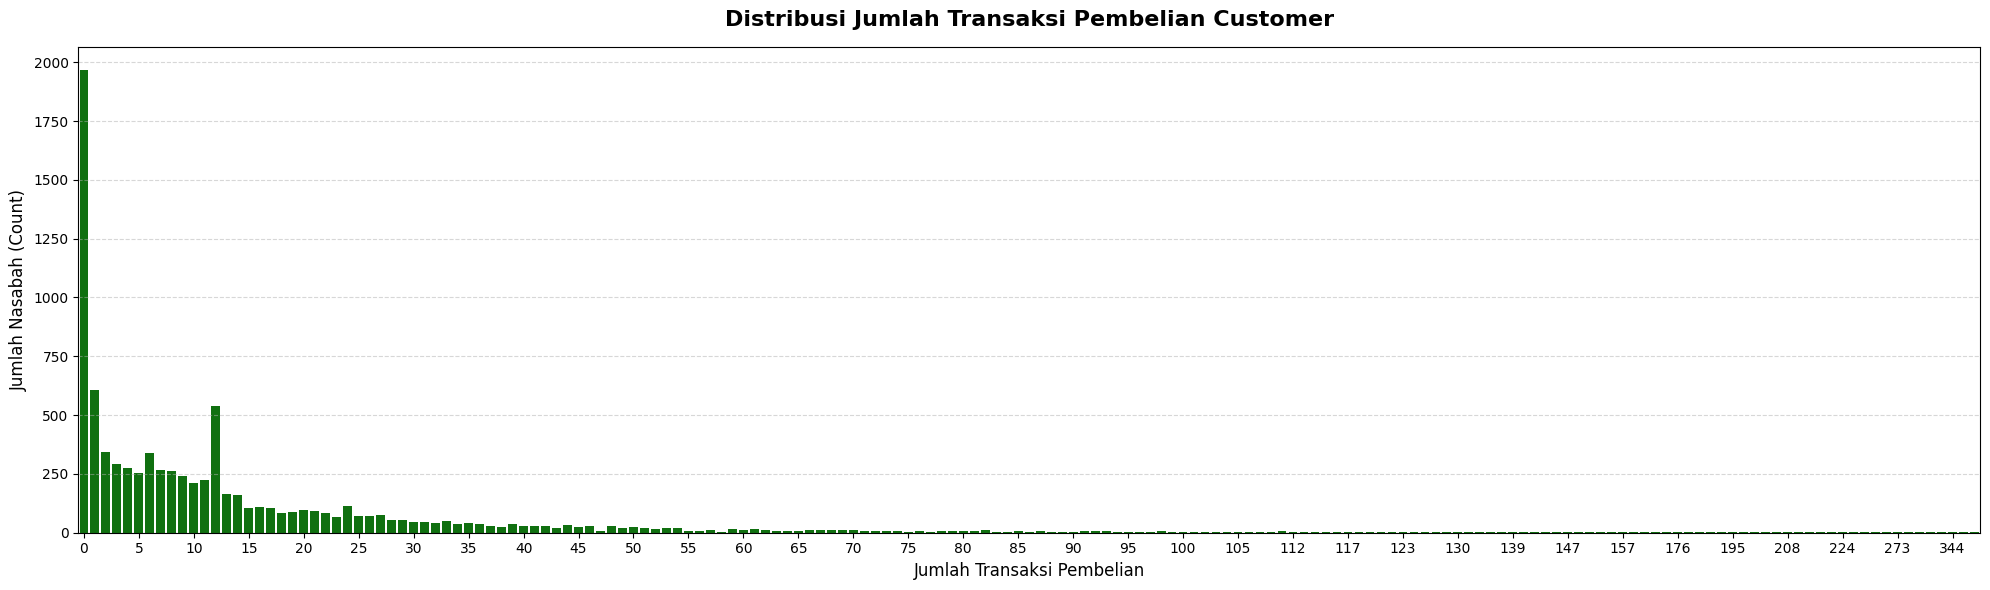

In [28]:
# Membuat visualisasi transaksi pembelian customer
plt.figure(figsize=(20, 6))
sns.countplot(data=customer, x='Transaksi_Pembelian', color='green')
plt.title('Distribusi Jumlah Transaksi Pembelian Customer', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Jumlah Transaksi Pembelian', fontsize=12)
plt.ylabel('Jumlah Nasabah (Count)', fontsize=12)

# Mengatur sumbu x
ax = plt.gca()
step = 5  # Atur jarak
ax.set_xticks(ax.get_xticks()[::step])

# Merotasi dan mengatur ukuran font sumbu X & Y
plt.xticks(rotation=0, fontsize=10)
plt.yticks(fontsize=10)

# Menambahkan garis grid tipis di latar belakang agar grafik lebih mudah dibaca
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Dari grafik diatas pada transaksi pembelian, terdapat banyak sekali customer yang tidak memiliki transaksi pembelian.

In [29]:
# analisa customer dengan total transaksi pmbelian 0
analisa_transaksinol = customer[(customer['Transaksi_Pembelian']==0)]
analisa_transaksinol.describe()

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor
count,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000,1967.0,1967.000000,1967.000000,1967.000000,1967.000000,1967.000000
mean,2208.551872,0.903136,0.399675,0.000122,0.444774,2007.458278,0.000763,0.000042,0.000763,0.276582,6.403152,0.0,4058.218946,1726.829231,1006.934432,0.046313,11.359939
std,2124.674226,0.198900,15.071288,0.005411,15.249476,2500.117089,0.023909,0.001879,0.023909,0.202463,8.182161,0.0,3287.744790,2815.951503,2617.727380,0.140966,1.497567
min,0.001146,0.090909,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,50.000000,0.049513,0.117036,0.000000,6.000000
25%,825.277817,0.909091,0.000000,0.000000,0.000000,376.484937,0.000000,0.000000,0.000000,0.100000,2.000000,0.0,1500.000000,395.260661,266.765542,0.000000,12.000000
50%,1502.444690,1.000000,0.000000,0.000000,0.000000,1221.854430,0.000000,0.000000,0.000000,0.250000,4.000000,0.0,3000.000000,803.519921,487.840515,0.000000,12.000000
75%,2877.462406,1.000000,0.000000,0.000000,0.000000,2713.655070,0.000000,0.000000,0.000000,0.363636,8.000000,0.0,6000.000000,1780.777957,1011.323846,0.000000,12.000000
max,14581.459140,1.000000,655.680000,0.240000,655.680000,26194.049540,1.000000,0.083333,1.000000,1.500000,123.000000,0.0,19000.000000,34107.074990,61031.618600,1.000000,12.000000


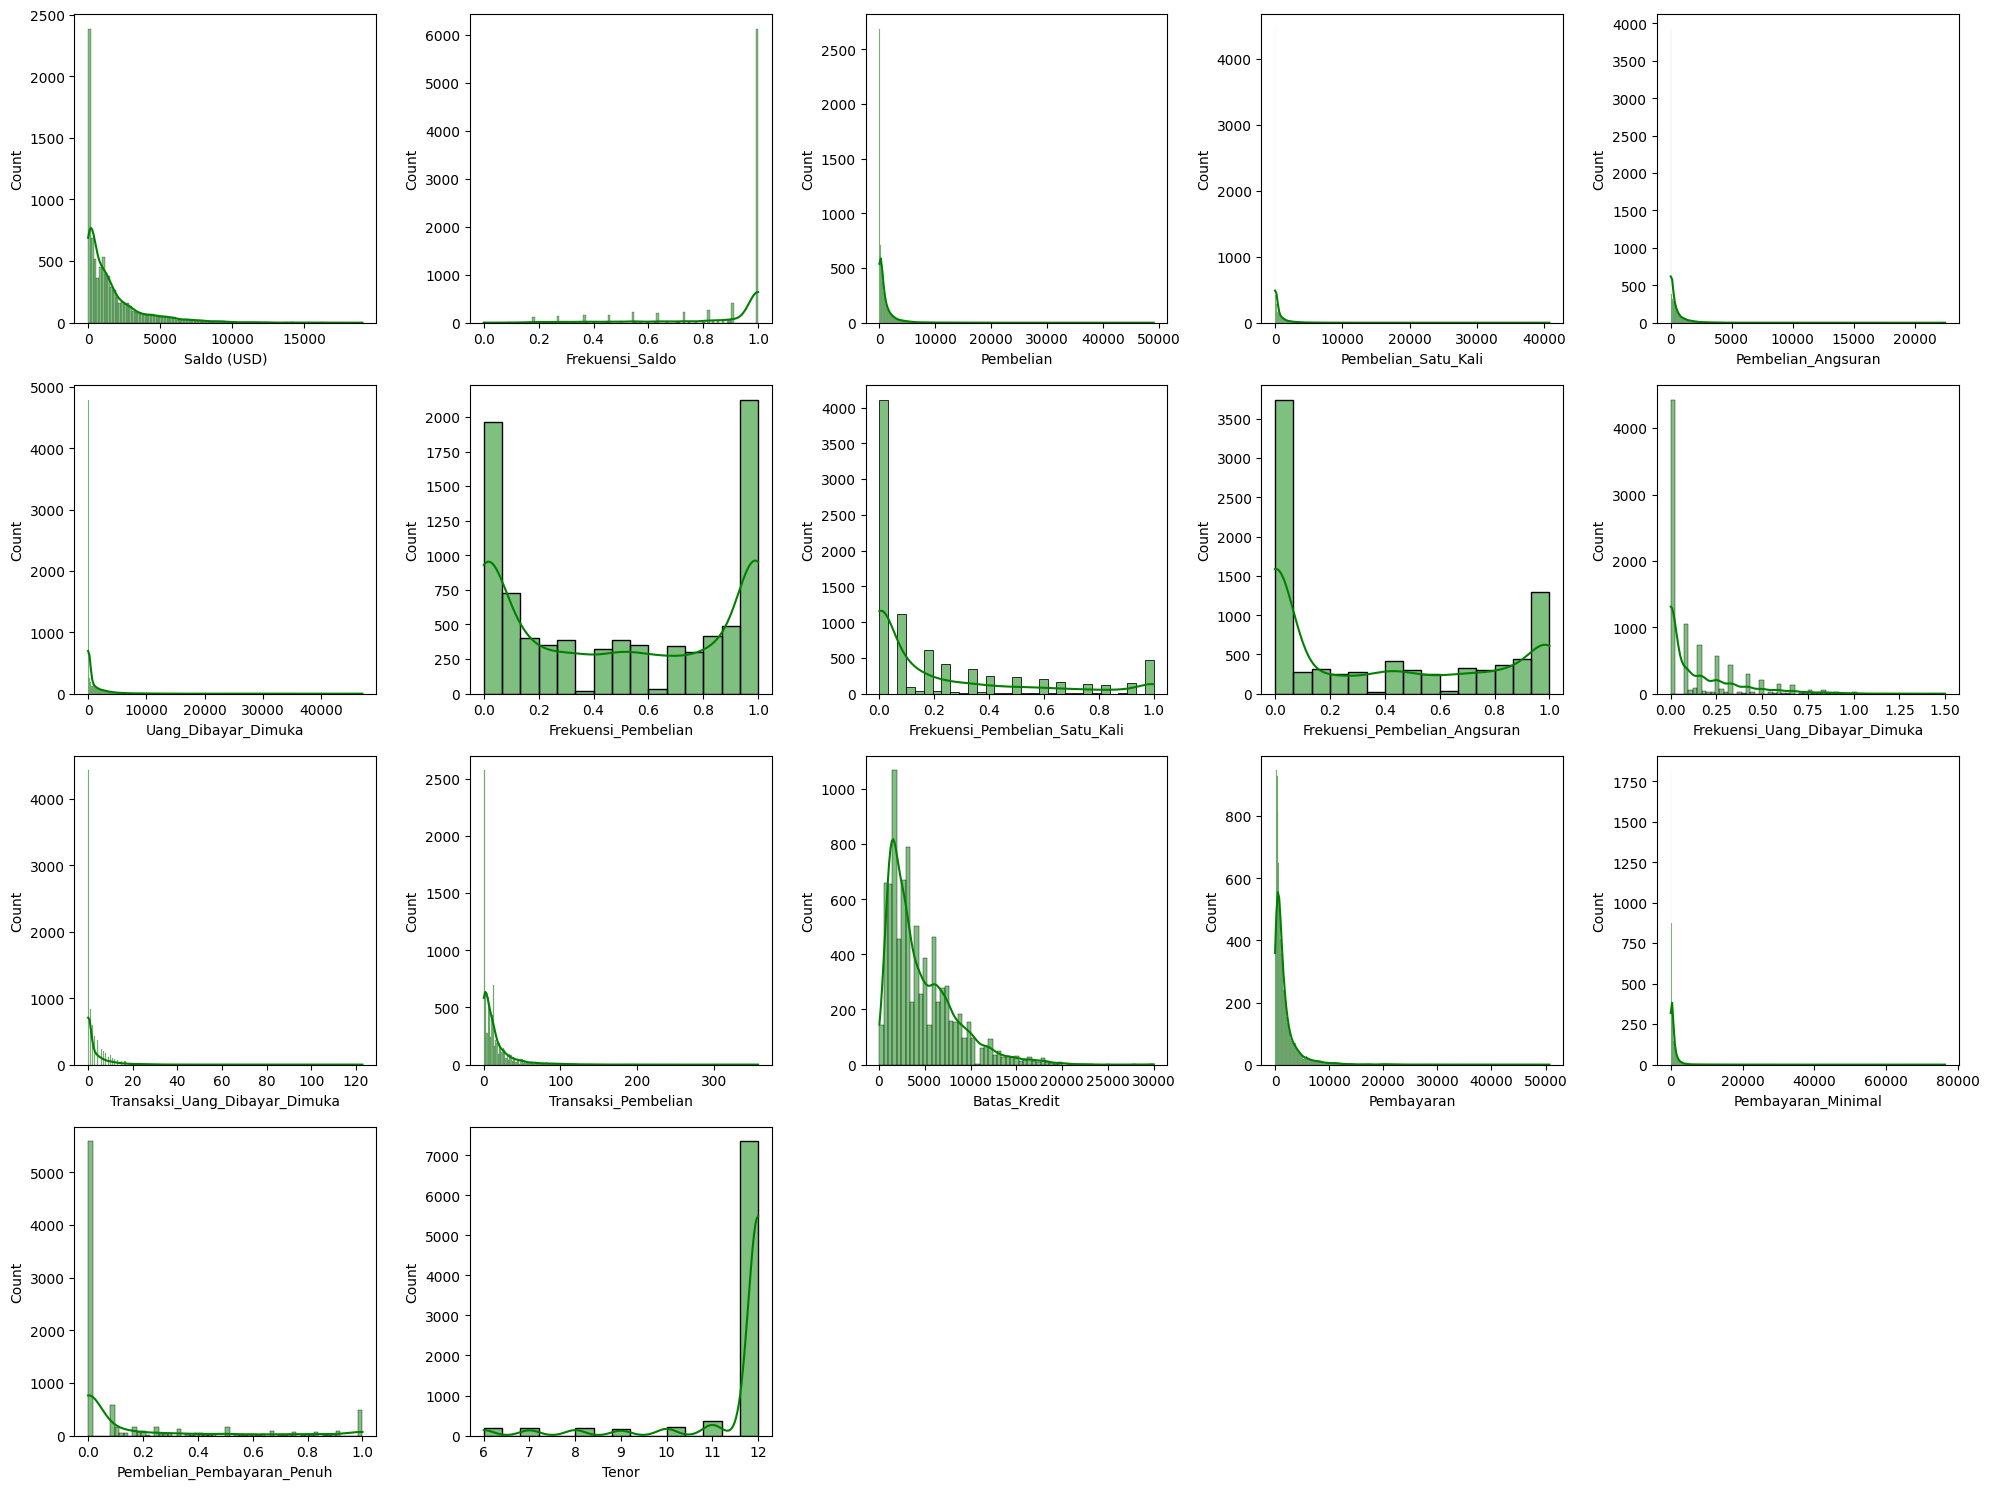

In [30]:
# Membuat histogram masing-masing variable

plt.figure(figsize=(20, 15))
num = analisa_transaksinol.select_dtypes(include=['int64', 'float64']).columns
for i in range(0, len(num)):
    plt.subplot(4, 5, i+1)
    sns.histplot(customer[num[i]], color='green', kde=True)

# 2. tight_layout()
plt.tight_layout()
plt.show()

Analisa customer yang memiliki catatan transaksi 0  :
1. Rata rata saldo sangat tinggi yaitu 2208.55.
2. Rata rata frekuensi mendekati satu, sehingga dapat dikatakan transaksi pembelian 0 adalah customer yang sering memperbarui saldo.
3. Berdasarkan catatan pembelian, customernya memiliki pola pembelian barang dengan harga yang murah karena dapat dilihat dari rata rata, Q1, Q2 dan Q3 semua menunjukkan angka 0.
4. Customer dengan transaksi 0 juga tergolong customer yang loyal karena didominasi oleh customer yang sudah bersama perusahaan selama 12 tahun.

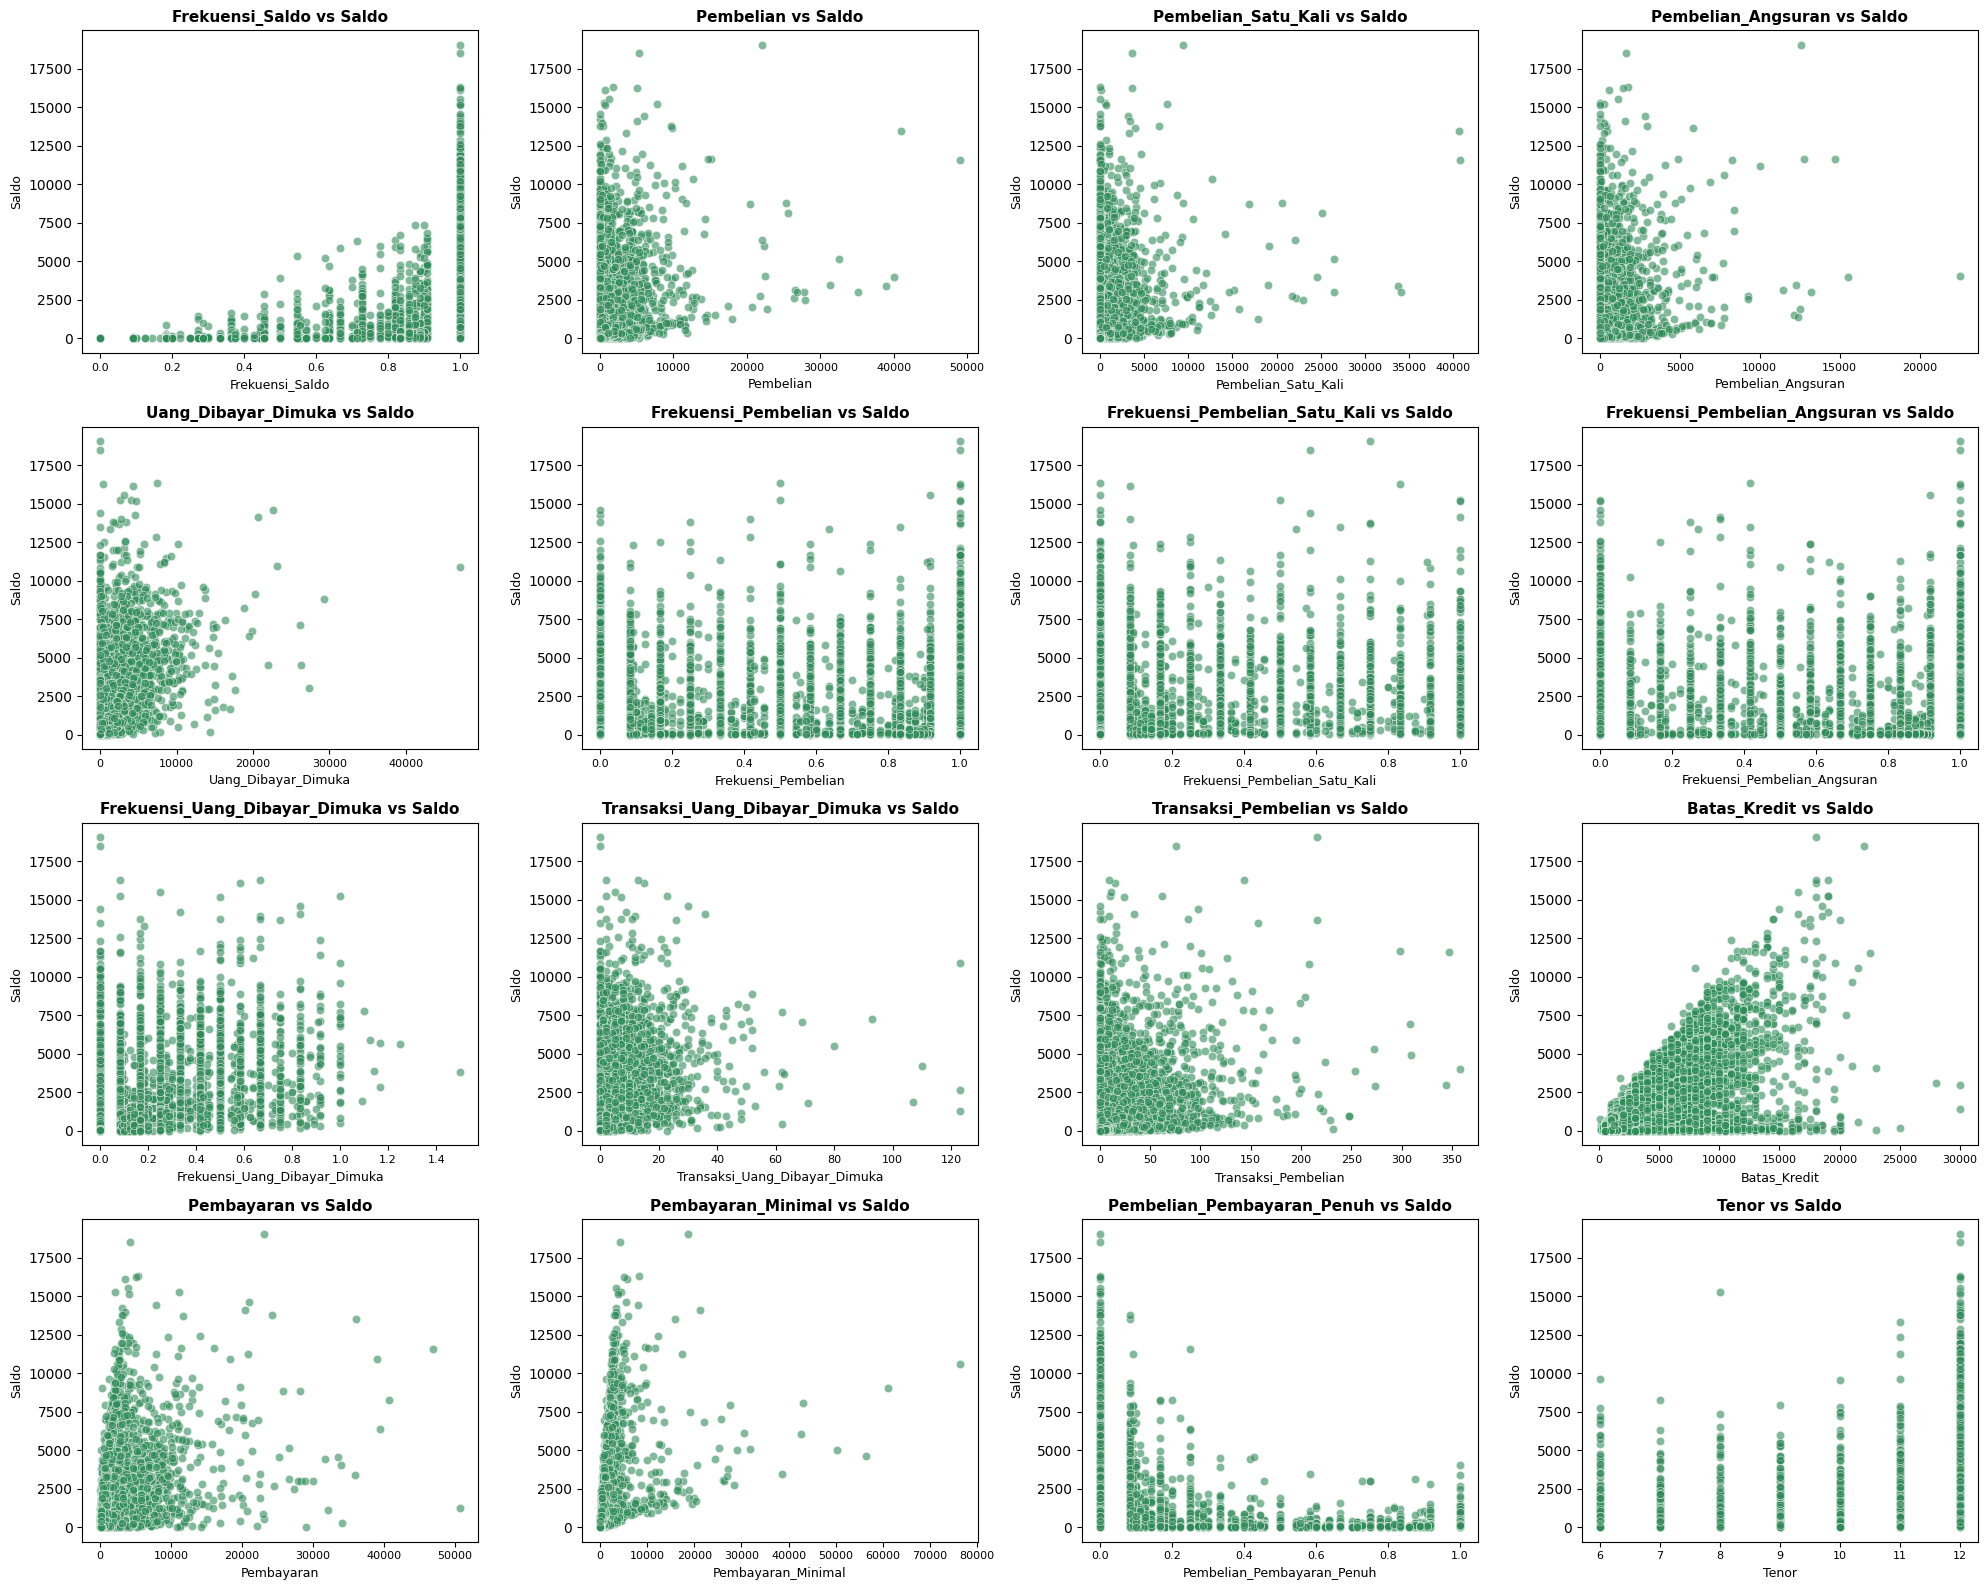

In [31]:
scatter_colomn = ['Frekuensi_Saldo', 'Pembelian', 'Pembelian_Satu_Kali',
       'Pembelian_Angsuran', 'Uang_Dibayar_Dimuka', 'Frekuensi_Pembelian',
       'Frekuensi_Pembelian_Satu_Kali', 'Frekuensi_Pembelian_Angsuran',
       'Frekuensi_Uang_Dibayar_Dimuka', 'Transaksi_Uang_Dibayar_Dimuka',
       'Transaksi_Pembelian', 'Batas_Kredit', 'Pembayaran',
       'Pembayaran_Minimal', 'Pembelian_Pembayaran_Penuh', 'Tenor']

# Ukuran kanvas
plt.figure(figsize=(20, 16))

for i in range(len(scatter_colomn)):
    # grid 4x4
    plt.subplot(4, 4, i + 1)
    sns.scatterplot(data=customer, x=scatter_colomn[i], y='Saldo (USD)', color='seagreen', alpha=0.6)

    # Menambahkan judul
    plt.title(f'{scatter_colomn[i]} vs Saldo', fontsize=11, fontweight='bold')
    plt.xlabel(scatter_colomn[i], fontsize=9)
    plt.ylabel('Saldo', fontsize=9)

    # Merotasi label sumbu X
    plt.xticks(rotation=0, fontsize=8)

# 4. plt.tight_layout
plt.tight_layout()
plt.show()

Grafik scatter plot diatas menunjukkan beberapa informasi diantaranya:
1. Customer yang memiliki saldo lebih dari 7500 pasti akan selalu memperbarui saldo
2. Adanya korelasi positif antar jumlah saldo dengan batas kredit, dimana semakin besar jumlah saldo maka batas kredit akan semakin besar.
3. Adanya korelasi negatif antara saldo dengan pembelian pembayaran sekali penuh, dimana semakin tinggi persentase pembayaran penuh, saldo customer cenderung semakin berkurang.

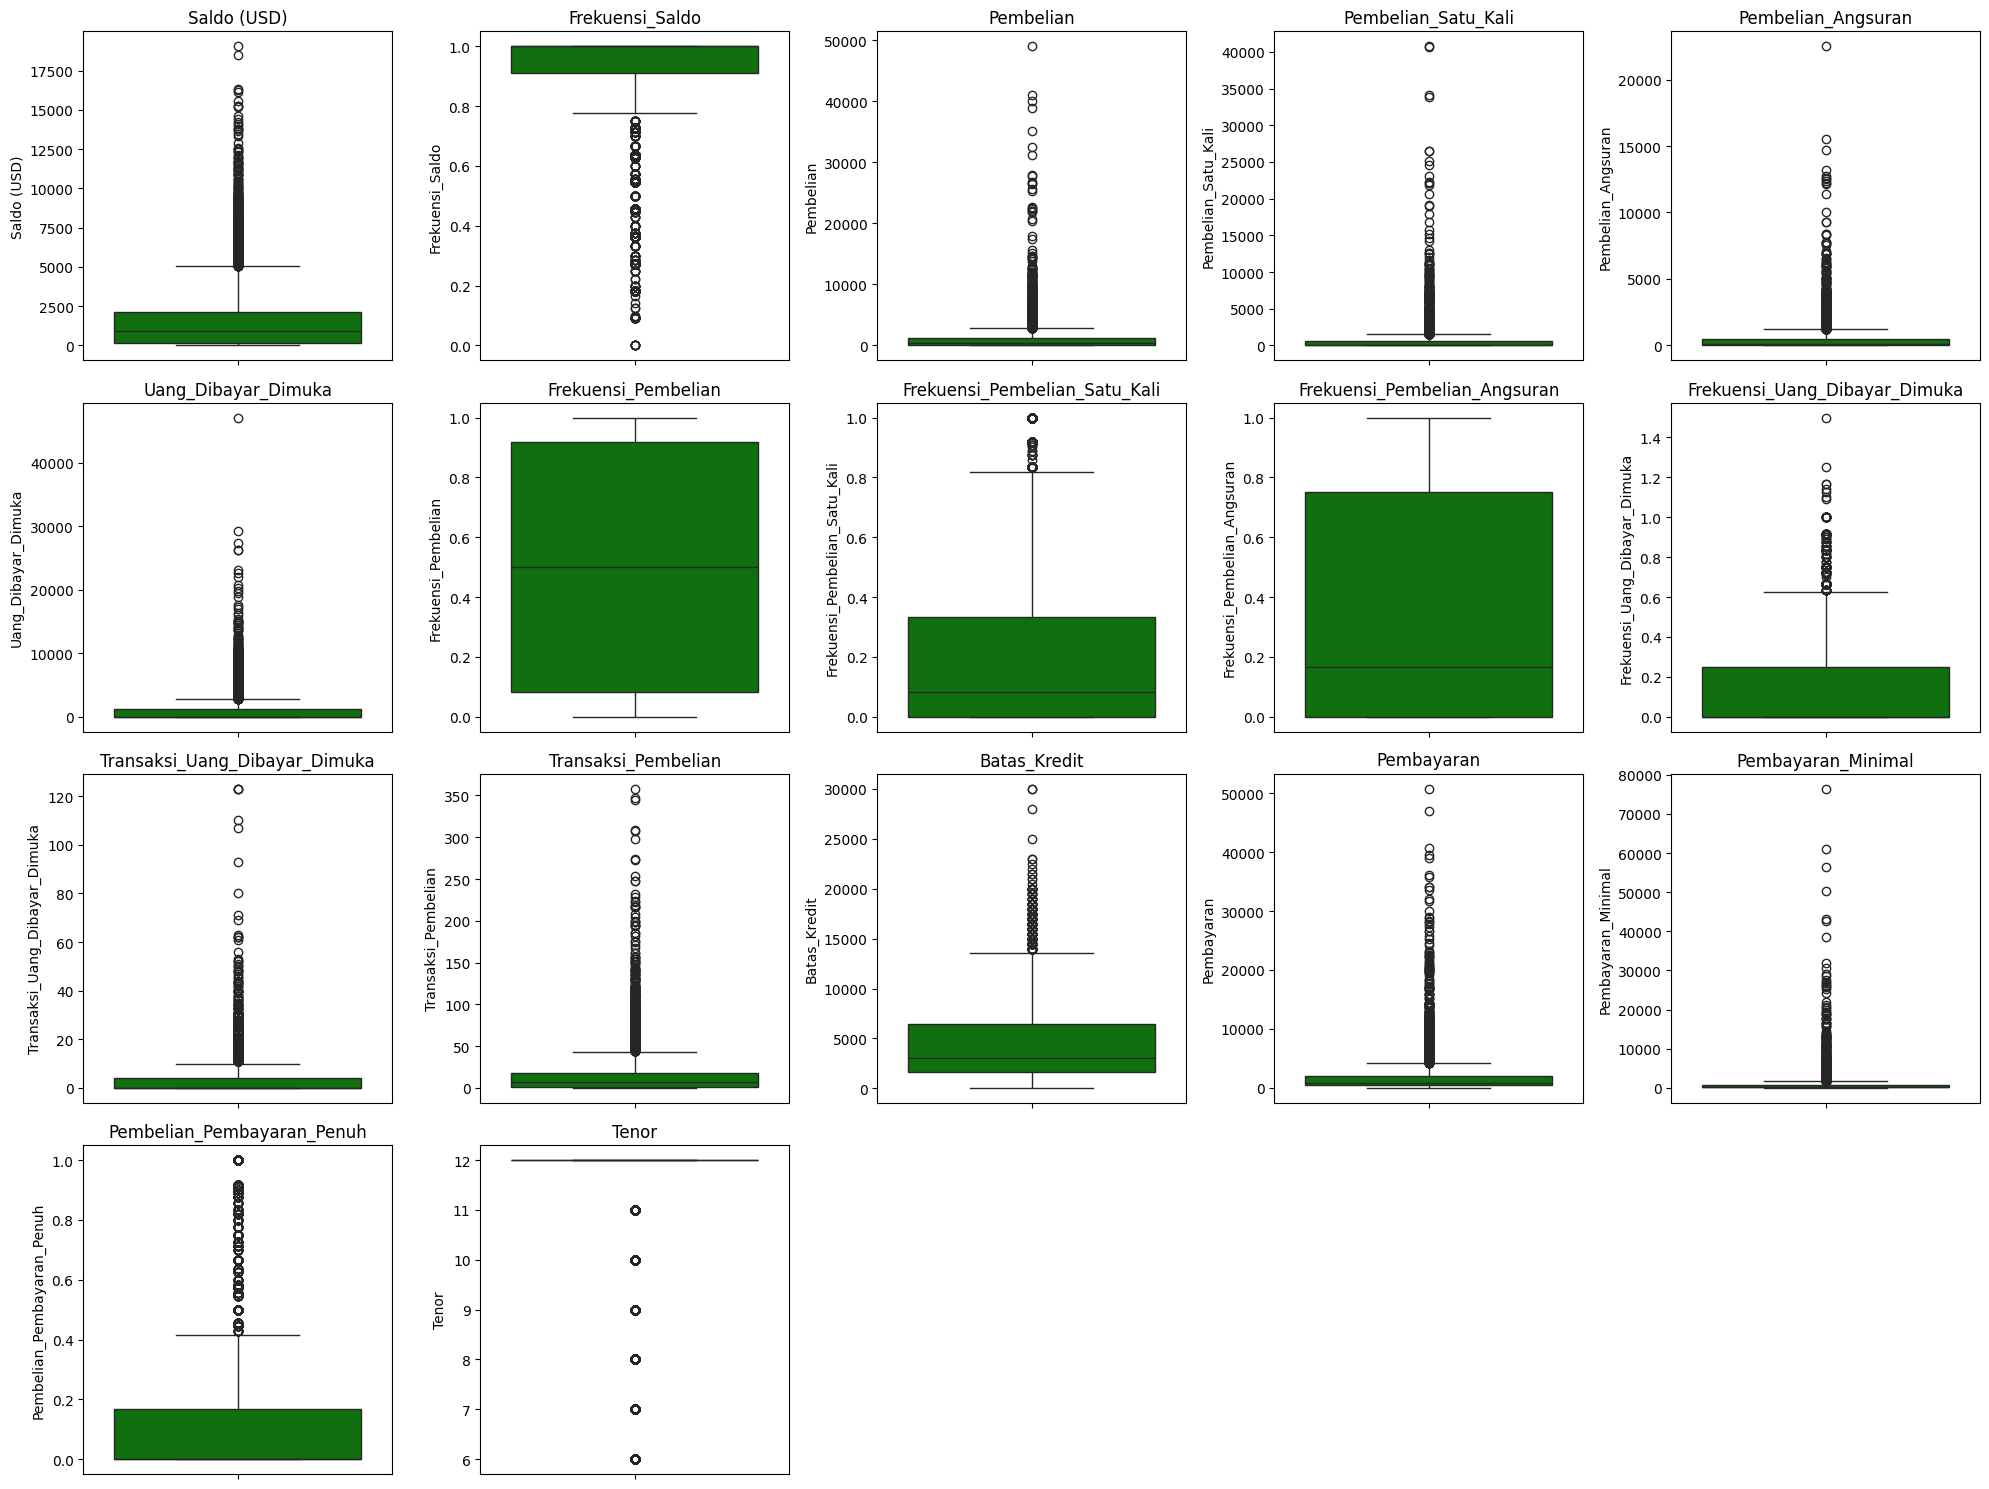

In [32]:
# Membuat boxplot masing-masing variable
plt.figure(figsize=(20, 15))

# Mengambil kolom dengan tipe data numerik
num = customer.select_dtypes(include=['int64', 'float64']).columns

# Looping untuk membuat subplot boxplot
for i in range(0, len(num)):
    plt.subplot(4, 5, i+1)
    sns.boxplot(y=customer[num[i]], color='green')
    plt.title(num[i])

# Merapikan tata letak agar tidak tumpang tindih
plt.tight_layout()
plt.show()

Ada banyak outlier, tapi saya tidak menghapusnya karena mungkin berisi informasi penting, jadi saya memperlakukan outlier sebagai nilai ekstrim.

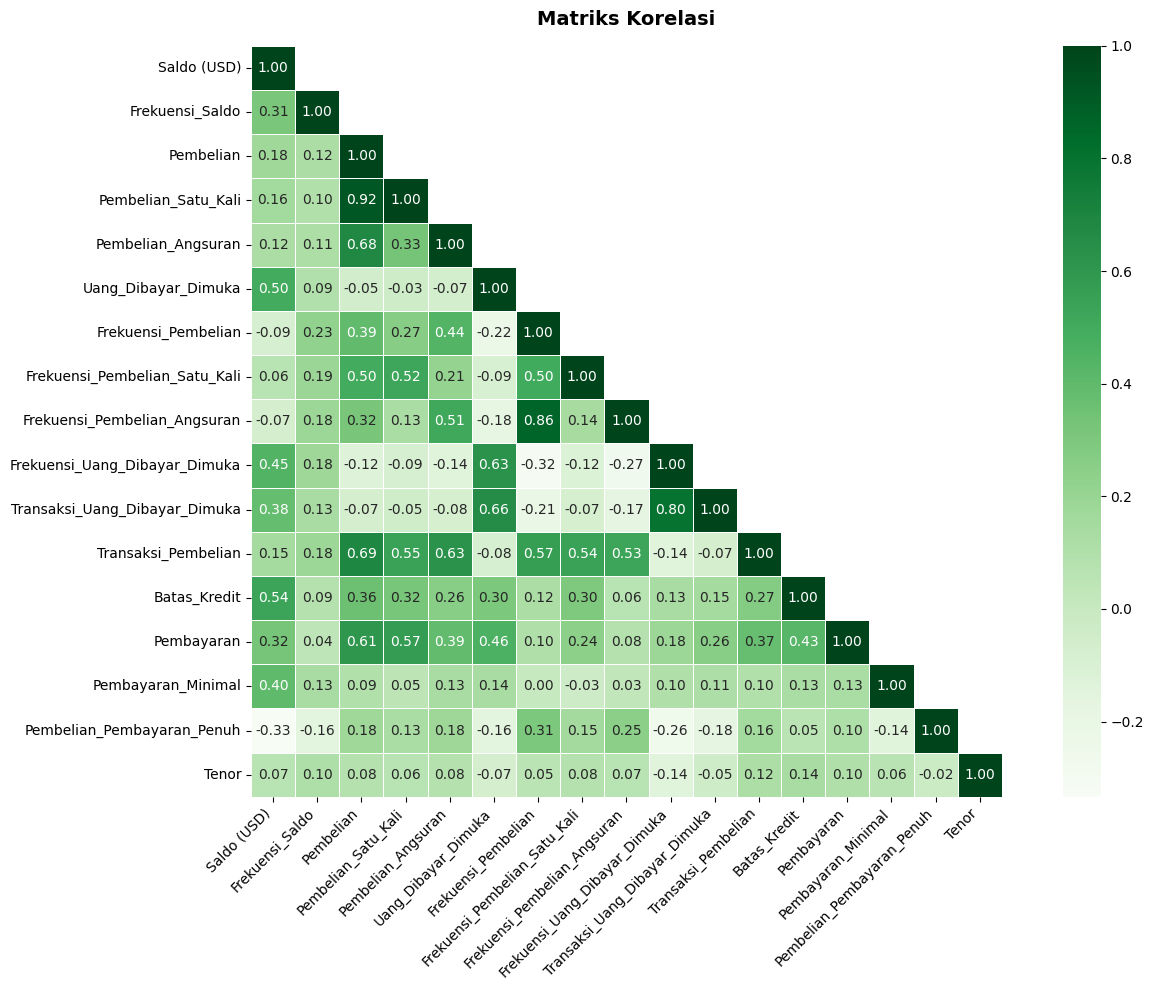

In [33]:
# Menyiapkan data korelasi
selected_columns = ['Saldo (USD)'] + scatter_colomn
corr_matrix = customer[selected_columns].corr()

# Membuat 'mask' (topeng) untuk menyembunyikan bagian segitiga atas
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

# Mengatur ukuran kanvas visualisasi
plt.figure(figsize=(14, 10))

# Membuat heatmap dengan parameter mask
sns.heatmap(
    corr_matrix,
    mask=mask,             # Menyembunyikan separuh bagian atas matriks
    annot=True,            # Menampilkan angka nilai korelasi di dalam kotak
    cmap='Greens',           # Tema warna gelap ke cerah (mirip dengan referensi gambar)
    fmt='.2f',             # Format angka 2 digit di belakang koma
    linewidths=0.5,        # Ketebalan garis pemisah antar kotak
    cbar=True,             # Menampilkan bar skala warna di samping
    square=True            # Membuat proporsi kotak menjadi simetris
)

# 5. Pengaturan judul dan label sumbu agar estetik
plt.title('Matriks Korelasi', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()
plt.show()

Dari grafik heatmap terlihat ada banyak variable yang saling berkolerasi kuat, cukup sulit untuk membuat model dengan melakukan pemilihan Variable secara manual, sehingga proses dalam pembuat model, pereduksian Variable akan dilakukan dengan bantuan PCA

Hasil reduksi dimensi menggunakan PCA informasi yang hilang sekitar 35% sehingga hal ini tidak menjadi masalah karena masih banyak infomasi yang tersimpan untuk menjelaskan perilaku customer

## Modelling

### Normalisasi Data

In [34]:
cluster_new = customer.copy()

cols_to_scale = [
    'Saldo (USD)', 'Pembelian', 'Pembelian_Satu_Kali',
    'Pembelian_Angsuran', 'Uang_Dibayar_Dimuka', 'Transaksi_Uang_Dibayar_Dimuka',
    'Transaksi_Pembelian', 'Batas_Kredit', 'Pembayaran',
    'Pembayaran_Minimal'
]

scaler = StandardScaler()
cluster_new[cols_to_scale] = scaler.fit_transform(cluster_new[cols_to_scale])

if 'Tenor' in cluster_new.columns:
    cluster_new.drop('Tenor', axis=1, inplace=True)

display(cluster_new.head().style.set_properties(**{'text-align': 'center'})\
    .set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}]))

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh
0,-0.744625,0.818182,-0.429184,-0.359160,-0.354826,-0.468655,0.166667,0.000000,0.083333,0.000000,-0.479437,-0.517623,-0.962575,-0.543942,-0.305508,0.000000
1,0.764152,0.909091,-0.473208,-0.359160,-0.458839,2.568556,0.000000,0.000000,0.000000,0.250000,0.099258,-0.597054,0.677204,0.796852,0.087689,0.222222
2,0.426602,1.000000,-0.116413,0.099909,-0.458839,-0.468655,1.000000,1.000000,0.000000,0.000000,-0.479437,-0.120467,0.813852,-0.399503,-0.099906,0.000000
3,-0.373910,1.000000,-0.465825,-0.349660,-0.458839,-0.468655,0.083333,0.083333,0.000000,0.000000,-0.479437,-0.557339,-0.907916,-0.380165,-0.261131,0.000000
4,0.099551,1.000000,0.142062,-0.359160,0.994815,-0.468655,0.666667,0.000000,0.583333,0.000000,-0.479437,-0.279329,-0.743938,-0.132119,0.650363,0.000000


### PCA

In [35]:
pca = PCA(n_components=2)
pca.fit(cluster_new)
pca_transform = pca.transform(cluster_new)
pca_transform

array([[-1.55267012, -0.69955162],
       [ 0.23016525,  2.51479069],
       [-0.06034134, -0.15656224],
       ...,
       [-1.40516987, -0.90180723],
       [-1.69684634, -0.51875087],
       [-0.65411491, -0.89522808]])

In [36]:
cluster_pca = pd.DataFrame(data=pca_transform,columns=['pca1','pca2'])
cluster_pca


# check the explained variance
print('explained variance:',pca.explained_variance_ratio_)

explained variance: [0.35949864 0.22780813]


### Penentuan Banyak Cluster

For n_clusters = 2, SSE: 36190.60 | Silhouette: 0.6146
For n_clusters = 3, SSE: 23884.39 | Silhouette: 0.5812
For n_clusters = 4, SSE: 17423.50 | Silhouette: 0.5623
For n_clusters = 5, SSE: 14073.62 | Silhouette: 0.4881
For n_clusters = 6, SSE: 11015.67 | Silhouette: 0.4872
For n_clusters = 7, SSE: 9503.52 | Silhouette: 0.4544
For n_clusters = 8, SSE: 8209.97 | Silhouette: 0.4374
For n_clusters = 9, SSE: 7398.02 | Silhouette: 0.4017


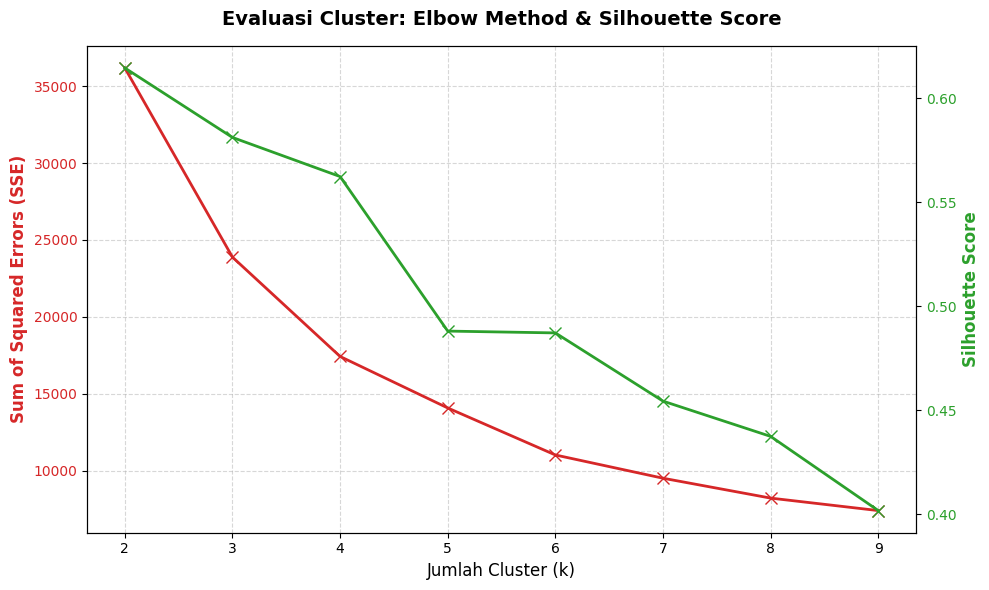

In [37]:
range_n_clusters = range(2, 10)
sum_of_squared_errors = []
silhouette_scores = []

# 1. Melakukan SATU looping untuk menghitung SSE dan Silhouette sekaligus (Lebih cepat!)
for n_clusters in range_n_clusters:
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    preds = km.fit_predict(cluster_pca)

    # Menghitung dan menyimpan SSE
    sse = km.inertia_
    sum_of_squared_errors.append(sse)

    # Menghitung dan menyimpan Silhouette Score
    score = silhouette_score(cluster_pca, preds)
    silhouette_scores.append(score)

    # Menampilkan print out gabungan
    print("For n_clusters = {}, SSE: {:.2f} | Silhouette: {:.4f}".format(n_clusters, sse, score))


# 2. Membuat Visualisasi Gabungan dengan Twin Axes (Dua Sumbu Y)
fig, ax1 = plt.subplots(figsize=(10, 6))

# ---- Sumbu Y Kiri (Untuk SSE - Warna Merah) ----
color_sse = 'tab:red'
ax1.set_xlabel('Jumlah Cluster (k)', fontsize=12)
ax1.set_ylabel('Sum of Squared Errors (SSE)', color=color_sse, fontsize=12, fontweight='bold')
ax1.plot(range_n_clusters, sum_of_squared_errors, marker='x', linestyle='-', color=color_sse, linewidth=2, markersize=8)
ax1.tick_params(axis='y', labelcolor=color_sse)
ax1.set_xticks(range_n_clusters)
ax1.grid(True, linestyle='--', alpha=0.5)

# ---- Sumbu Y Kanan (Untuk Silhouette - Warna Biru) ----
ax2 = ax1.twinx()  # Membuat sumbu Y kedua yang berbagi sumbu X yang sama
color_sil = 'tab:green'
ax2.set_ylabel('Silhouette Score', color=color_sil, fontsize=12, fontweight='bold')
ax2.plot(range_n_clusters, silhouette_scores, marker='x', linestyle='-', color=color_sil, linewidth=2, markersize=8)
ax2.tick_params(axis='y', labelcolor=color_sil)

# Menambahkan judul keseluruhan
plt.title('Evaluasi Cluster: Elbow Method & Silhouette Score', fontsize=14, fontweight='bold', pad=15)

fig.tight_layout()
plt.show()

Hasil grafik elbow terlihat bahwa K mean berada pada 3 dan 4 serta hasil dari evaluasi model menunjukkan score silhoutte untuk K mean terbaik berada pada K = 2 dengan skor 61,38% namun hal ini kurang masuk akal menurut saya jika memilih K = 2, dan setelah melakukan beberapa percobaan untuk K=3 dan K=4, saya menemukan Kluster yang masuk akal adalah K=3 karena pola prilaku customer lebih terlihat.

### Pemodelan Menggunakan K-Means

In [38]:
# Memodelkan data dengan k-means
kmean= KMeans(3)
kmean.fit(customer)
labels=kmean.labels_

# Menggabungkan data yang sudah di cluster
clusters=pd.concat([customer, pd.DataFrame({'cluster':labels})], axis=1)
clusters.head()

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor,cluster
0,40.900749,0.818182,95.40,0.00,95.40,0.000000,0.166667,0.000000,0.083333,0.00,0,2,1000.0,201.802084,139.509787,0.000000,12,0
1,3202.467416,0.909091,0.00,0.00,0.00,6442.945483,0.000000,0.000000,0.000000,0.25,4,0,7000.0,4103.032597,1072.340217,0.222222,12,2
2,2495.148862,1.000000,773.17,773.17,0.00,0.000000,1.000000,1.000000,0.000000,0.00,0,12,7500.0,622.066742,627.284787,0.000000,12,2
3,817.714335,1.000000,16.00,16.00,0.00,0.000000,0.083333,0.083333,0.000000,0.00,0,1,1200.0,678.334763,244.791237,0.000000,12,0
4,1809.828751,1.000000,1333.28,0.00,1333.28,0.000000,0.666667,0.000000,0.583333,0.00,0,8,1800.0,1400.057770,2407.246035,0.000000,12,0


Visualisasi ini membuktikan bahwa algoritma berhasil memisahkan pelanggan ke dalam tiga segmen perilaku yang berbeda, mulai dari kelompok yang sangat seragam (Cluster 2) hingga kelompok yang perilakunya sangat bervariasi (Cluster 1). Secara garis besar, grafik ini memperlihatkan batas yang jelas antara mayoritas pelanggan beraktivitas standar yang menumpuk di sebelah kiri, berbanding dengan kelompok pelanggan kelas atas atau *outliers* yang tersebar luas di sebelah kanan.

## Hasil

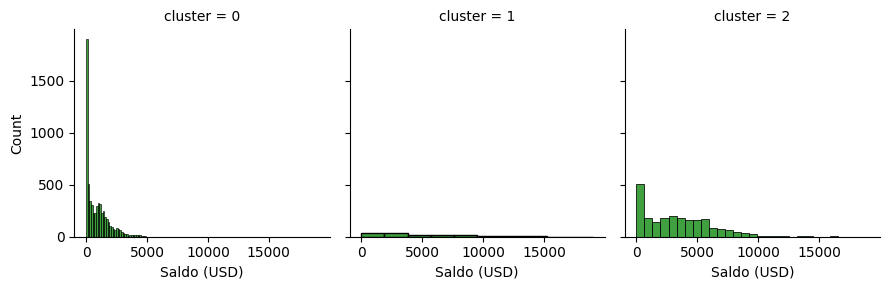

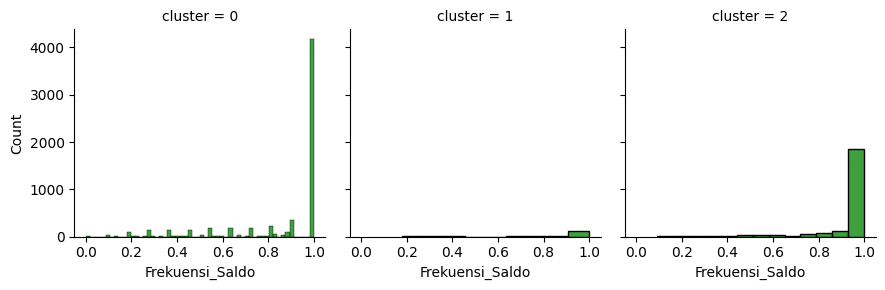

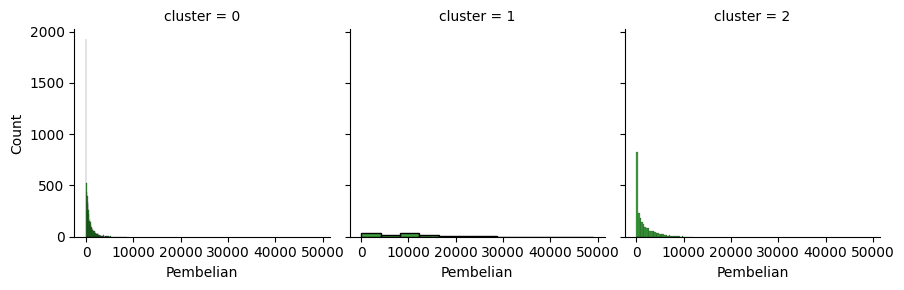

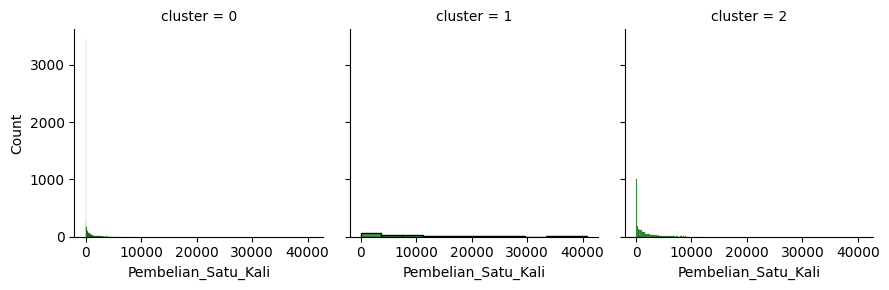

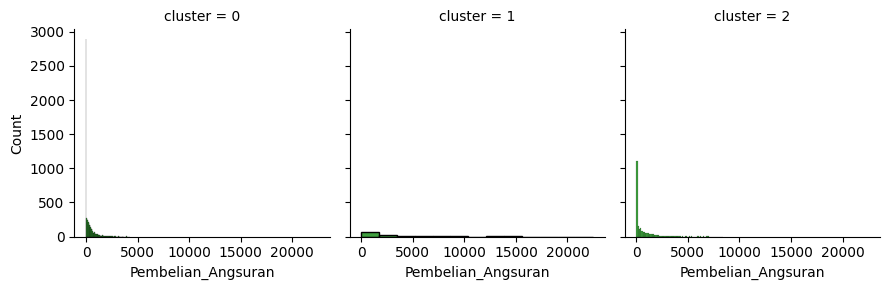

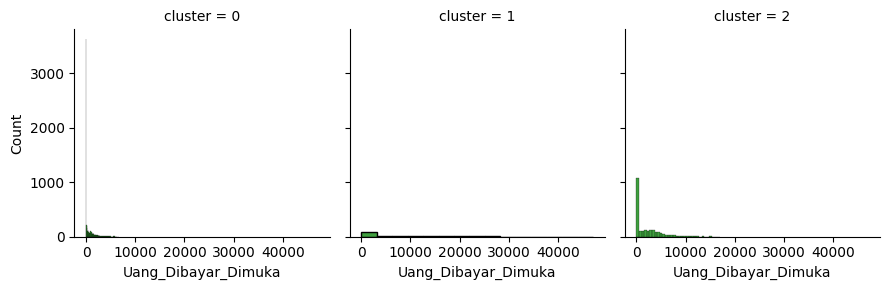

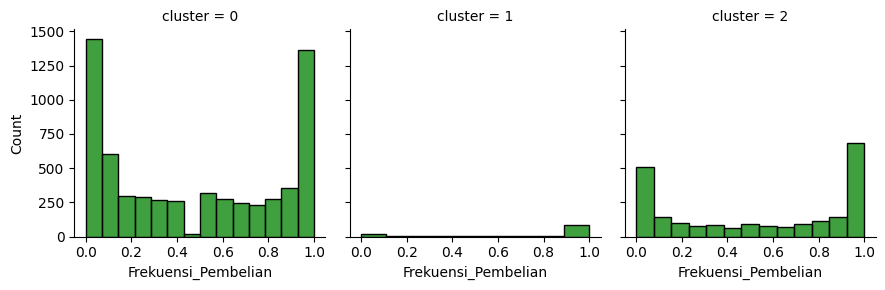

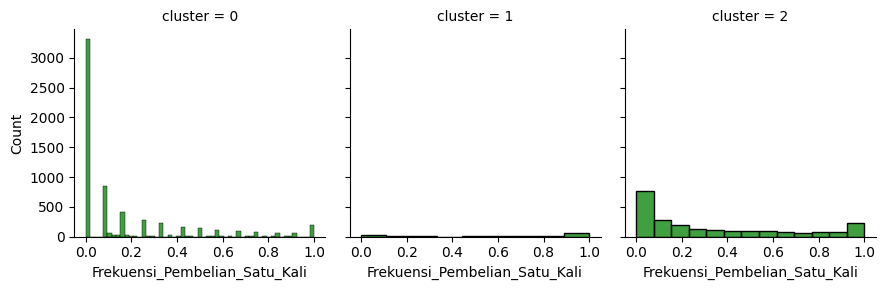

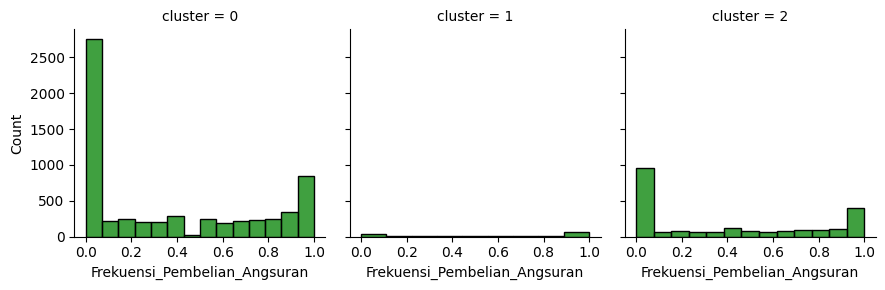

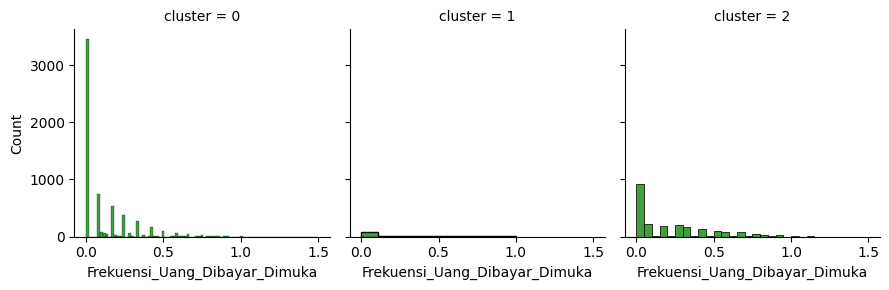

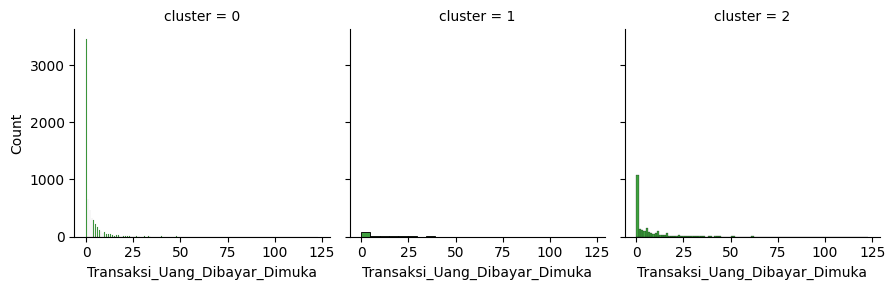

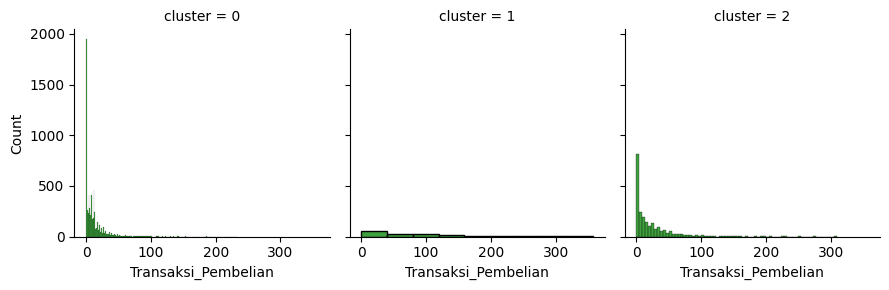

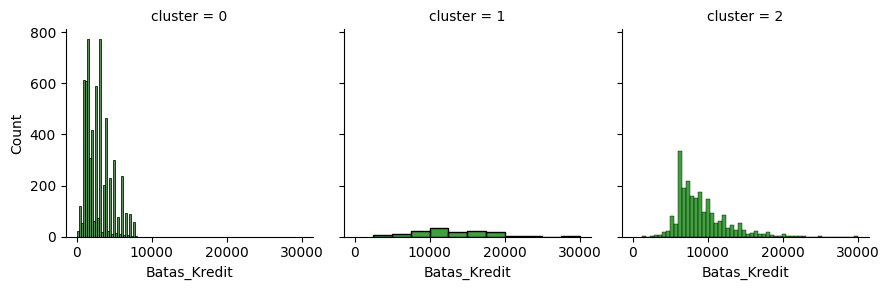

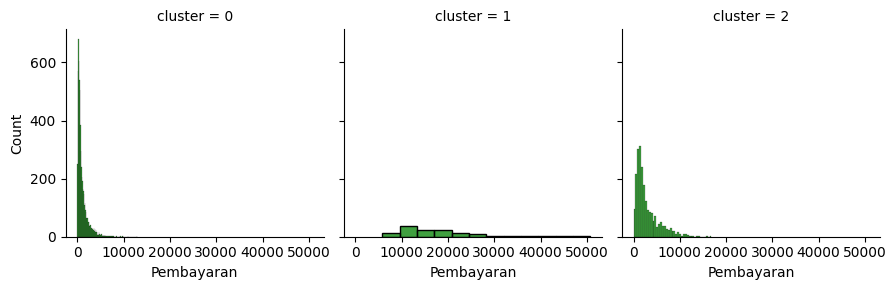

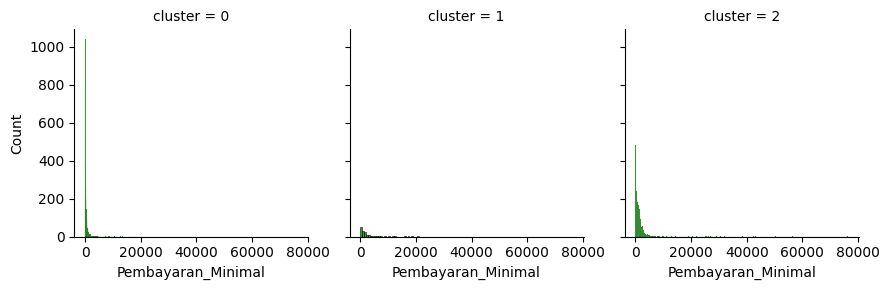

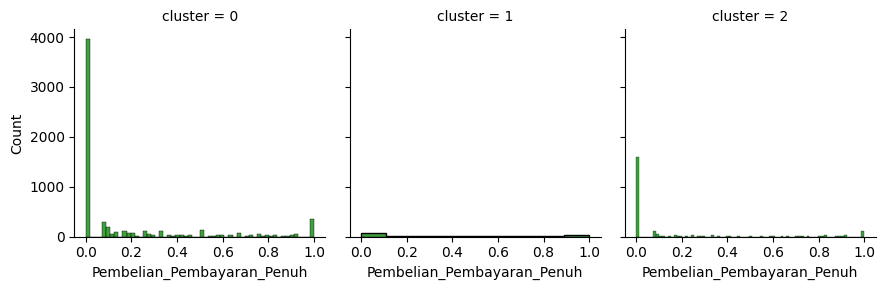

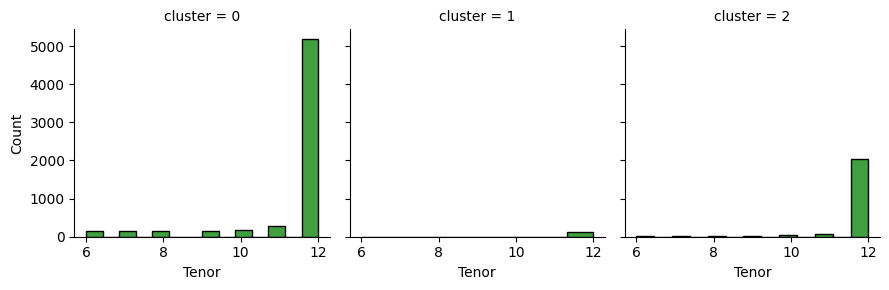

In [39]:
kolom_numerik = [col for col in clusters.select_dtypes(include=['int64', 'float64']).columns if col != 'cluster']

# 2. Looping untuk membuat FacetGrid
for i in kolom_numerik:
    grid = sns.FacetGrid(clusters, col='cluster')
    grid.map(sns.histplot, i, color='green')
    plt.show()

In [40]:
clusters.groupby('cluster').mean().style.set_properties(**{'text-align': 'center'}).set_table_styles([{'selector': 'th', 'props': [('text-align', 'center')]}])

,Saldo (USD),Frekuensi_Saldo,Pembelian,Pembelian_Satu_Kali,Pembelian_Angsuran,Uang_Dibayar_Dimuka,Frekuensi_Pembelian,Frekuensi_Pembelian_Satu_Kali,Frekuensi_Pembelian_Angsuran,Frekuensi_Uang_Dibayar_Dimuka,Transaksi_Uang_Dibayar_Dimuka,Transaksi_Pembelian,Batas_Kredit,Pembayaran,Pembayaran_Minimal,Pembelian_Pembayaran_Penuh,Tenor
cluster,,,,,,,,,,,,,,,,,
0,876.822935,0.876025,616.402920,318.497154,298.217704,498.894469,0.473287,0.157024,0.356344,0.108767,2.292781,10.899792,2741.287592,1032.613742,572.667425,0.163995,11.453178
1,4833.015572,0.914621,10530.779774,7429.905414,3101.039774,5430.509513,0.742299,0.586639,0.597388,0.230829,9.255639,84.413534,12489.097744,17905.869447,2474.073451,0.329257,11.842105
2,3416.610916,0.946520,1597.688027,995.611560,602.393821,2104.099425,0.544373,0.318827,0.389892,0.211959,5.791223,22.388741,8983.556979,2916.016925,1576.964679,0.136294,11.741135



Cluster 0

Saldo : Low <br>
Frekuensi Saldo : High <br>
Pembelian : Low <br>
Frekuensi Pembelian : Low <br>
Pembayaran Minimal : Low <br>
Batas Kredit : Low <br>

Cluster 1

Saldo : Medium <br>
Frekuensi Saldo : High <br>
Pembelian : Medium <br>
Frekuensi Pembelian : Medium <br>
Pembayaran Minimal : Medium <br>
Batas Kredit : Medium <br>

Cluster 2

Saldo : High <br>
Frekuensi Saldo : High <br>
Pembelian : High <br>
Frekuensi Pembelian : High <br>
Pembayaran Minimal : High <br>
Batas Kredit : High <br>

____________________________________________________________________________

Cluster 0: Kelompok pelanggan ini menunjukkan sekelompok pelanggan yang memiliki saldo rendah, pengeluaran kecil (pembelian rendah) dengan batas kredit terendah.

Cluster 1: Kelompok pelanggan ini menunjukkan sekelompok pelanggan yang memiliki saldo menengah, pembelanja (menengah) dengan batas kredit menengah.

Cluster 2: Kelompok pelanggan ini menunjukkan sekelompok pelanggan yang memiliki saldo tinggi dan penarikan tunai, frekuensi pembelian rendah dengan batas kredit tinggi.

## Kesimpulan


- Cluster 0, rekomendasikan **silver credit card** karena ini adalah kartu yang paling banyak dimiliki. Secara umum, pemegang kartu kredit baru akan menerima kartu perak dan mereka dapat meningkatkannya nanti. Kartu silver memiliki limit kredit paling rendah yaitu sekitar Rp 4 juta hingga Rp 7 juta. Pemegang kartu harus memiliki gaji bulanan minimal Rp 3 juta. Kelebihan dari kartu ini adalah limit yang tidak terlalu tinggi. <br>

- Cluster 1, rekomendasikan **gold credit card**. Pemegang kartu harus memiliki penghasilan rutin bulanan sekitar Rp 5 juta hingga Rp 10 juta. Limit kredit berkisar antara Rp 10 juta hingga Rp 40 juta, tergantung bank penerbit kartu kredit. Kelebihan dari jenis kartu ini adalah limit yang cukup besar. Jadi, ini memungkinkan Anda untuk membeli/memiliki barang-barang mahal lebih cepat. Anda bisa menggunakannya untuk mencicil barang-barang berbujet besar seperti sepeda motor atau smartphone. Namun, semakin tinggi batas kartu kredit, semakin tinggi biaya tahunan yang harus Anda bayar.

- Cluster 2, kartu **platinum credit card** dengan level tertinggi. Kartu kredit Platinum hanya dimiliki oleh segelintir orang karena tidak mudah untuk mendapatkan kartu karena prosedur yang ketat. Kartu kredit platinum memiliki limit tinggi mulai dari Rp 40 juta hingga Rp 1 miliar. Pemegang kartu harus memiliki penghasilan minimal Rp 180 juta per tahun dan memiliki riwayat kredit yang baik.

## Referensi

https://medium.com/analytics-vidhya/credit-card-customers-segmentation-bc3c5c87ddc